# EEG-Based Epileptic Seizure Detection

## Comparing Linear and Non-Linear Classifiers on High-Dimensional Neural Signals

**EE559 - Machine Learning I | University of Southern California | Spring 2026**

| | |
|---|---|
| **Dataset** | UCI Epileptic Seizure Recognition (ID: 388) |
| **Task** | Binary classification: Seizure (class 1) vs. Non-Seizure (classes 2-5) |
| **Models (from scratch)** | Logistic Regression, LDA, Perceptron, SVM (kernel), MLP |
| **Novel contribution** | Phase-space trajectory entropy (Approximate Entropy) as a seizure feature |

---

**By: Anisha Pattanayak**

**9117117967**

## 0. Environment Setup and Imports

In [48]:
#  Standard library 
import warnings
warnings.filterwarnings('ignore')
import os, time

#  Numerical / scientific 
import numpy as np
import pandas as pd
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.stats import skew, kurtosis

#  Visualisation 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns

#  sklearn (for data utilities and metric helpers ONLY) 
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score
)
# Note: scipy.stats.mcnemar was removed in scipy 1.11+
# We implement McNemar's test from scratch in Section 12 using scipy.stats.chi2

#  Reproducibility 
SEED = 42
np.random.seed(SEED)

#  Plot style 
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'text.color':       '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#222',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'figure.dpi':       120
})
PALETTE = ['#00d4ff', '#ff4d6d', '#a8ff78', '#f7c59f', '#c77dff']
print('Environment ready')

Environment ready


## 1. Data Acquisition

We load the dataset from a local CSV (downloaded from Kaggle). No manual preprocessing is required before loading.

In [ ]:
# ── Download ──────────────────────────────────────────────────────────────────
# Dataset: https://www.kaggle.com/datasets/harunshimanto/epileptic-seizure-recognition
# Download the CSV from Kaggle and place it next to this notebook before running.
import os

df = pd.read_csv('Epileptic_Seizure_Recognition.csv')
y_raw = df[['y']].copy()
X_raw = df.drop(columns=['y', 'Unnamed: 0'], errors='ignore').copy()
print(f'Loaded | X: {X_raw.shape}  y: {y_raw.shape}')
df.head()

Loaded | X: (11500, 178)  y: (11500, 1)


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [ ]:
#  Binary label encoding 
# Class 1 = epileptic seizure  ->  label 1
# Classes 2-5 = non-seizure    ->  label 0
CLASS_NAMES_MULTI = {
    1: 'Seizure',
    2: 'Tumor area EEG',
    3: 'Healthy area EEG',
    4: 'Eyes closed',
    5: 'Eyes open'
}

y_multi = y_raw.values.ravel().astype(int)
y       = (y_multi == 1).astype(int)
X       = X_raw.values.astype(float)

print(f'Samples: {X.shape[0]} | Features: {X.shape[1]}')
print(f'Seizure (1): {y.sum()} | Non-seizure (0): {(y==0).sum()}')
print(f'Positive rate: {y.mean():.2%}')

Samples: 11500 | Features: 178
Seizure (1): 2300 | Non-seizure (0): 9200
Positive rate: 20.00%


## 2. Exploratory Data Analysis (EDA)

### 2.1 Data Cleaning and Initial View

- Loading raw data
- Null values check
- Basic feature formatting

In [ ]:
#  Null check 
print('Total missing values in dataset:', df.isnull().sum().sum())

X_raw_eda = df.drop(columns=[df.columns[0], 'y'])
y_raw_eda = df['y']
y_binary  = (y_raw_eda == 1).astype(int)

print('Data successfully loaded and checked!')

Total missing values in dataset: 0
Data successfully loaded and checked!


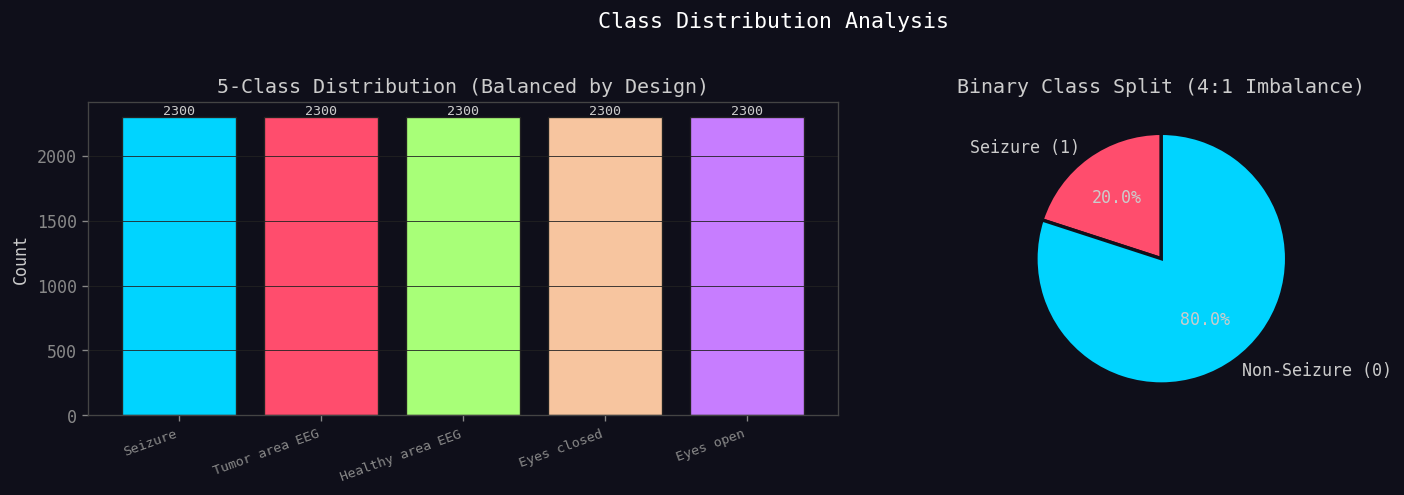

In [52]:
#  2.1 Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = pd.Series(y_multi).value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor='#222', linewidth=0.8)
axes[0].set_xticks(counts.index)
axes[0].set_xticklabels([CLASS_NAMES_MULTI[i] for i in counts.index],
                         rotation=20, ha='right', fontsize=8)
axes[0].set_title('5-Class Distribution (Balanced by Design)', color='#ccc')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y')
for i, v in zip(counts.index, counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=8, color='#ccc')

binary_counts = [y.sum(), (y==0).sum()]
axes[1].pie(binary_counts, labels=['Seizure (1)', 'Non-Seizure (0)'],
            colors=[PALETTE[1], PALETTE[0]], autopct='%1.1f%%',
            startangle=90, textprops={'color': '#ccc'},
            wedgeprops={'edgecolor': '#0f0f1a', 'linewidth': 2})
axes[1].set_title('Binary Class Split (4:1 Imbalance)', color='#ccc')

plt.suptitle('Class Distribution Analysis', fontsize=13, color='#fff', y=1.02)
plt.tight_layout()
plt.show()

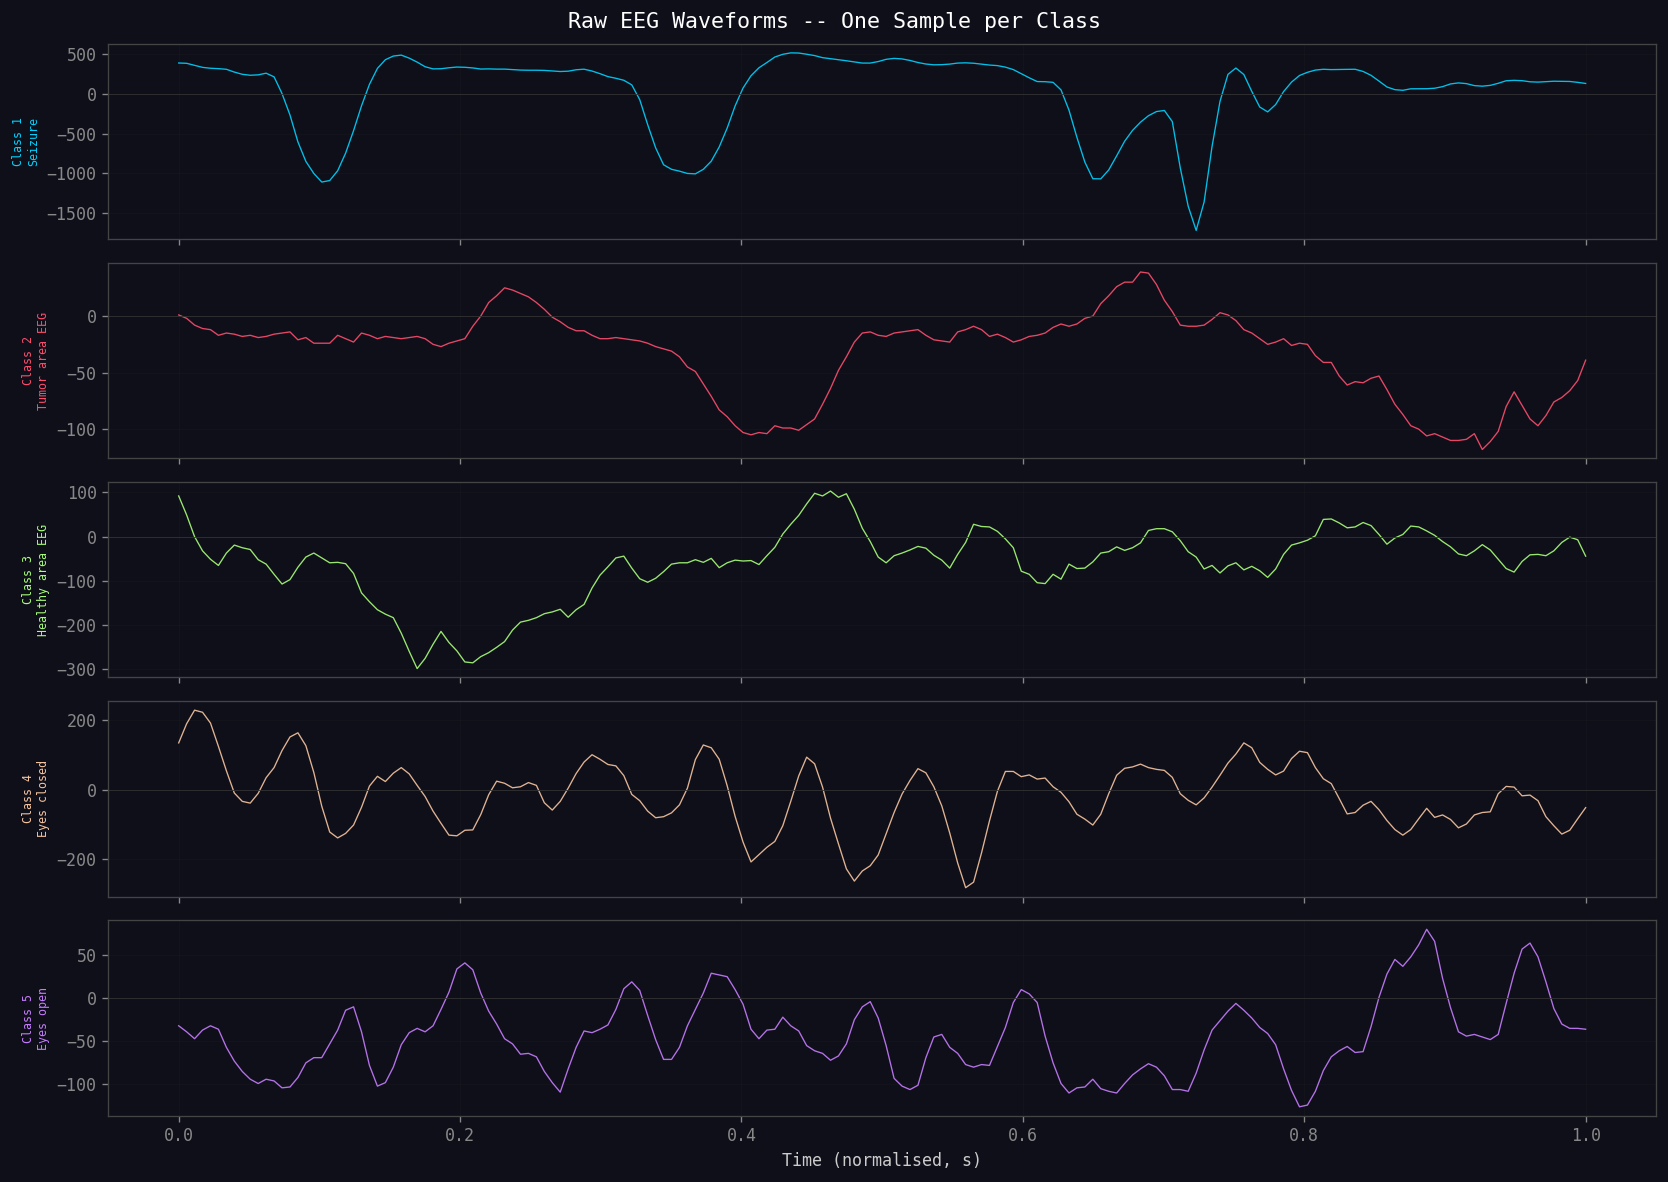

In [ ]:
#  2.2 Raw EEG waveform visualisation 
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
t = np.linspace(0, 1, 178)

for cls_idx, (cls, label) in enumerate(CLASS_NAMES_MULTI.items()):
    idx    = np.where(y_multi == cls)[0][0]
    signal = X[idx]
    axes[cls_idx].plot(t, signal, color=PALETTE[cls_idx], lw=0.8, alpha=0.9)
    axes[cls_idx].set_ylabel(f'Class {cls}\n{label}', fontsize=7, color=PALETTE[cls_idx])
    axes[cls_idx].axhline(0, color='#333', lw=0.5)
    axes[cls_idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (normalised, s)')
plt.suptitle('Raw EEG Waveforms  One Sample per Class', fontsize=13, color='#fff')
plt.tight_layout()
plt.show()

In [54]:
#  2.3 Statistical summary per class 
summary_rows = []
for cls in sorted(CLASS_NAMES_MULTI):
    mask   = y_multi == cls
    subset = X[mask].ravel()
    summary_rows.append({
        'Class':  f'{cls} - {CLASS_NAMES_MULTI[cls]}',
        'Mean':   round(subset.mean(), 2),
        'Std':    round(subset.std(),  2),
        'Skew':   round(skew(subset),      3),
        'Kurt':   round(kurtosis(subset),  3),
        'Min':    round(subset.min(), 1),
        'Max':    round(subset.max(), 1),
    })
summary_df = pd.DataFrame(summary_rows).set_index('Class')
print('=== Statistical Summary per EEG Class ===')
display(summary_df)

=== Statistical Summary per EEG Class ===


,Mean,Std,Skew,Kurt,Min,Max
Class,,,,,,
1 - Seizure,-4.76,341.15,-0.385,2.890,-1885.0,2047.0
2 - Tumor area EEG,-6.20,90.35,3.971,76.682,-1147.0,2047.0
3 - Healthy area EEG,-8.88,59.39,-0.046,1.821,-412.0,623.0
4 - Eyes closed,-12.51,70.69,-0.035,0.580,-424.0,360.0
5 - Eyes open,-6.26,48.34,0.036,0.285,-288.0,294.0


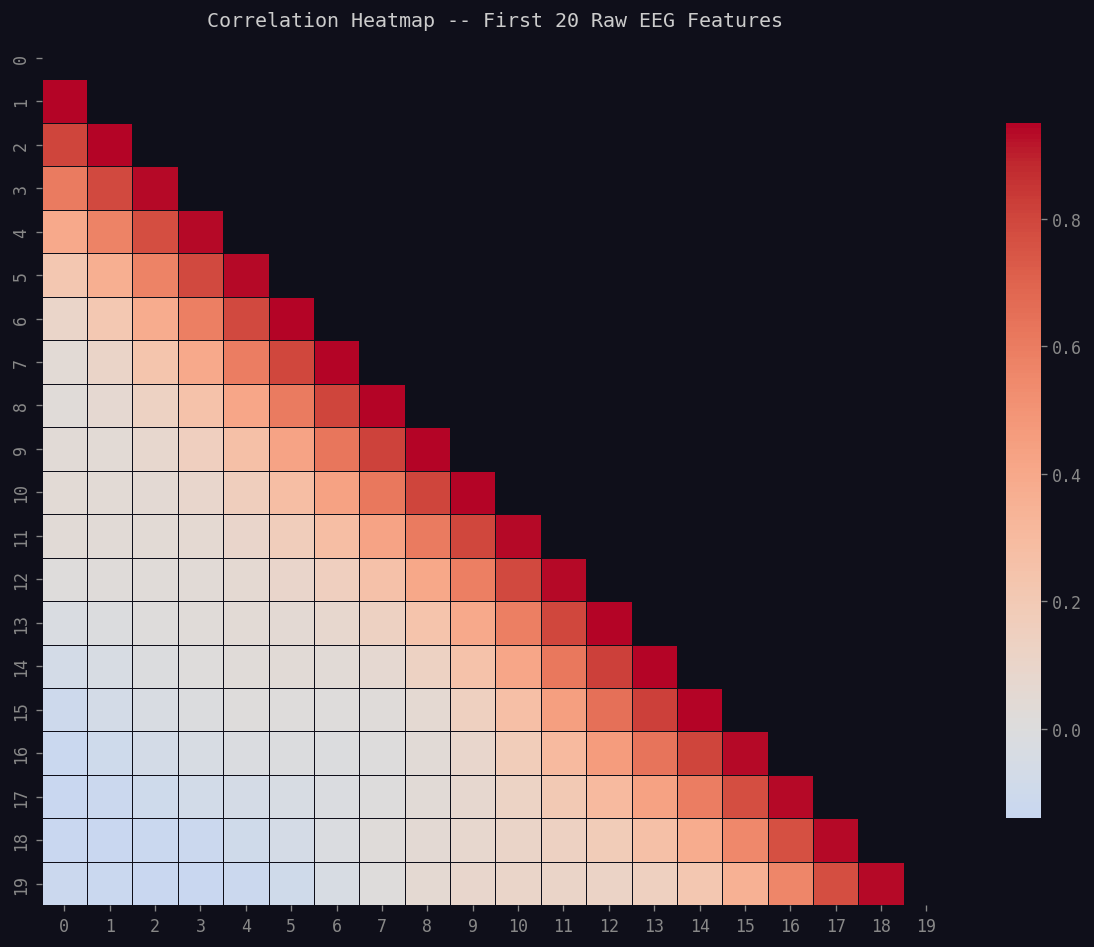

In [ ]:
#  2.4 Correlation heatmap (first 20 raw features) 
fig, ax = plt.subplots(figsize=(10, 8))
corr = pd.DataFrame(X[:, :20]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            linewidths=0.3, linecolor='#0f0f1a',
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap  First 20 Raw EEG Features', color='#ccc')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

The 178 raw time-point values represent a 1-second EEG window sampled at 178 Hz.
We extract three families of features **from scratch**:

| Family | Features |
|-|-|
| Statistical | mean, std, skewness, kurtosis, min, max, range, RMS, zero-crossing rate, Q1, Q3, MAD |
| Frequency-domain (FFT) | delta (0.5-4 Hz), theta (4-8 Hz), alpha (8-13 Hz), beta (13-30 Hz), gamma (30-80 Hz) band power, spectral entropy |
| **Novel: Phase-space entropy** | Approximate entropy of the Takens embedding trajectory - captures nonlinear EEG dynamics |

In [ ]:
FS = 178.0  # sampling frequency (Hz)

#  Band power helper 
def band_power(signal, fs, low, high):
    """Compute average power in [low, high] Hz band using FFT."""
    N      = len(signal)
    freqs  = fftfreq(N, 1.0 / fs)
    fft_v  = np.abs(fft(signal)) ** 2
    mask   = (freqs >= low) & (freqs < high)
    return fft_v[mask].mean() if mask.any() else 0.0

#  Spectral entropy (Shannon entropy of normalised power spectrum) 
def spectral_entropy(signal):
    """Compute Shannon entropy of the normalised FFT power spectrum."""
    N     = len(signal)
    power = np.abs(fft(signal)[:N // 2]) ** 2
    power /= (power.sum() + 1e-12)
    return -np.sum(power * np.log(power + 1e-12))

#  Novel feature: Approximate Entropy (ApEn) 
def approximate_entropy(signal, m=2, r_factor=0.2):
    """
    Approximate Entropy (Pincus 1991).
    m        : template length
    r_factor : tolerance = r_factor * std(signal)
    """
    N = len(signal)
    r = r_factor * np.std(signal) + 1e-12
    def phi(m_):
        templates = np.array([signal[i:i + m_] for i in range(N - m_)])
        count = np.array([
            np.sum(np.max(np.abs(templates - templates[i]), axis=1) <= r)
            for i in range(len(templates))
        ])
        return np.log(count / (N - m_ + 1e-12)).mean()
    return abs(phi(m) - phi(m + 1))

#  Zero crossing rate 
def zero_crossing_rate(signal):
    """Fraction of consecutive sample pairs with a sign change."""
    return ((signal[:-1] * signal[1:]) < 0).sum() / len(signal)

print('Feature extraction functions defined')

Feature extraction functions defined


In [ ]:
#  Extract all features (row by row) -
print('Extracting features... (this may take ~2-3 minutes for ApEn)')
t0 = time.time()

feature_matrix = []
for i, sig in enumerate(X):
    if i % 1000 == 0:
        print(f'  [{i}/{len(X)}] elapsed: {time.time()-t0:.1f}s')
    sig_ds = sig[::4]  # downsample for ApEn only
    row = [
        sig.mean(), sig.std(), skew(sig), kurtosis(sig),
        sig.min(), sig.max(), sig.max() - sig.min(),
        np.sqrt(np.mean(sig ** 2)), zero_crossing_rate(sig),
        np.percentile(sig, 25), np.percentile(sig, 75),
        np.median(np.abs(sig - np.median(sig))),
        band_power(sig, FS, 0.5,  4), band_power(sig, FS, 4,    8),
        band_power(sig, FS, 8,   13), band_power(sig, FS, 13,  30),
        band_power(sig, FS, 30,  80), spectral_entropy(sig),
        approximate_entropy(sig_ds, m=2, r_factor=0.2),
    ]
    feature_matrix.append(row)

FEATURE_NAMES = [
    'mean', 'std', 'skewness', 'kurtosis', 'min', 'max', 'range', 'rms',
    'zcr', 'q1', 'q3', 'mad',
    'delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power',
    'spectral_entropy', 'approx_entropy'
]
X_feat = np.array(feature_matrix)
print(f'\nFeature matrix shape: {X_feat.shape} | Total time: {time.time()-t0:.1f}s')

Extracting features... (this may take ~2-3 minutes for ApEn)
  [0/11500] elapsed: 0.0s
  [1000/11500] elapsed: 1.4s
  [2000/11500] elapsed: 3.0s
  [3000/11500] elapsed: 4.5s
  [4000/11500] elapsed: 6.1s
  [5000/11500] elapsed: 7.7s
  [6000/11500] elapsed: 9.2s
  [7000/11500] elapsed: 10.6s
  [8000/11500] elapsed: 12.0s
  [9000/11500] elapsed: 13.5s
  [10000/11500] elapsed: 14.9s
  [11000/11500] elapsed: 16.4s

Feature matrix shape: (11500, 19) | Total time: 17.1s


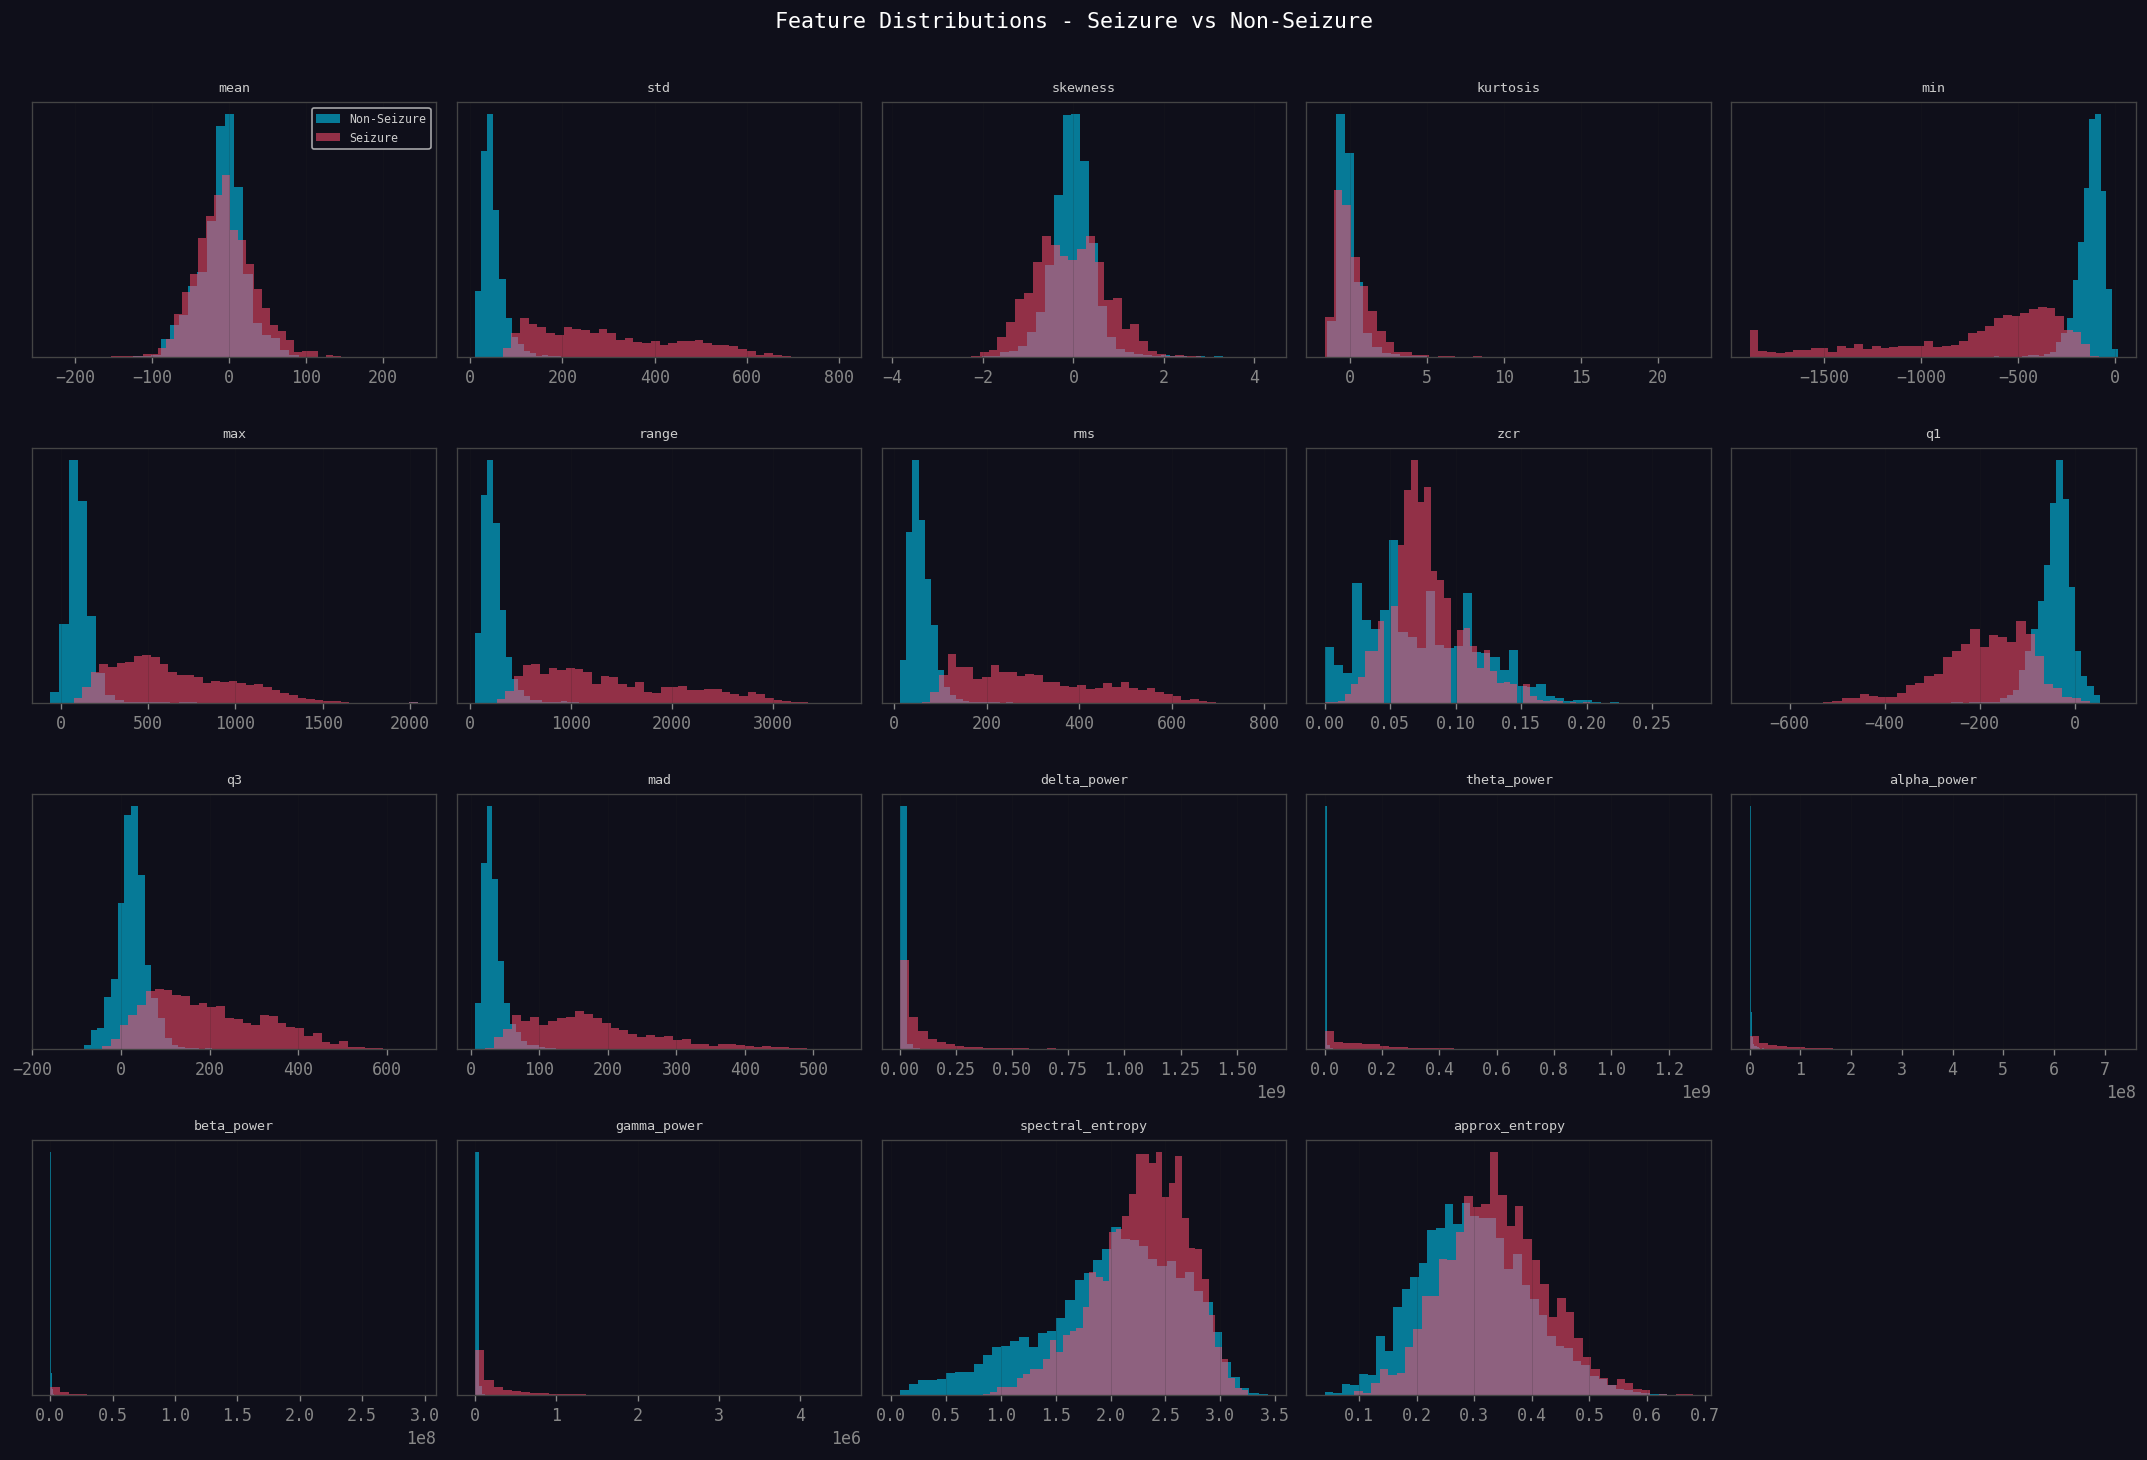

In [58]:
# - Feature distributions: seizure vs non-seizure -
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes = axes.ravel()

for i, fname in enumerate(FEATURE_NAMES):
    ax = axes[i]
    for cls, color, label in [(0, PALETTE[0], 'Non-Seizure'), (1, PALETTE[1], 'Seizure')]:
        vals = X_feat[y == cls, i]
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(fname, fontsize=8)
    ax.set_yticks([])
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions - Seizure vs Non-Seizure',
             fontsize=13, color='#fff', y=1.01)
plt.tight_layout()
plt.show()

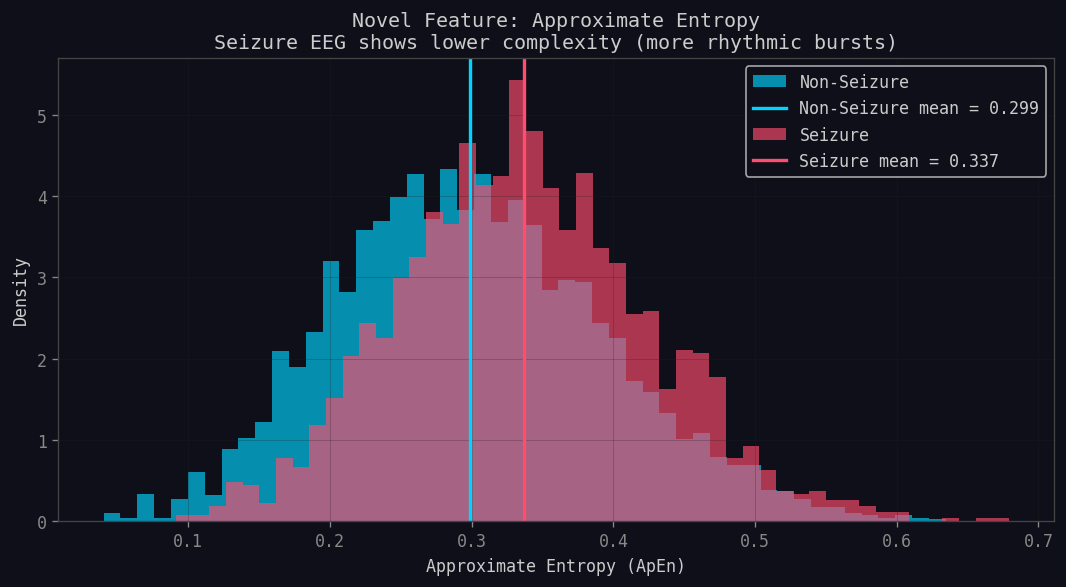

Two-sample t-test on ApEn: t = -17.503, p = 1.03e-67
Statistically significant separation!


In [ ]:
#  Novel Feature Spotlight: Approximate Entropy -
fig, ax = plt.subplots(figsize=(9, 5))
for cls, color, label in [(0, PALETTE[0], 'Non-Seizure'), (1, PALETTE[1], 'Seizure')]:
    vals = X_feat[y == cls, FEATURE_NAMES.index('approx_entropy')]
    ax.hist(vals, bins=50, alpha=0.65, color=color, label=label, density=True)
    ax.axvline(vals.mean(), color=color, lw=2, ls='-',
               label=f'{label} mean = {vals.mean():.3f}')

ax.set_xlabel('Approximate Entropy (ApEn)')
ax.set_ylabel('Density')
ax.legend()
ax.set_title('Novel Feature: Approximate Entropy\nSeizure EEG shows lower complexity (more rhythmic bursts)', color='#ccc')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

t_stat, p_val = stats.ttest_ind(
    X_feat[y == 0, FEATURE_NAMES.index('approx_entropy')],
    X_feat[y == 1, FEATURE_NAMES.index('approx_entropy')]
)
print(f'Two-sample t-test on ApEn: t = {t_stat:.3f}, p = {p_val:.2e}')
print('Statistically significant separation!' if p_val < 0.05 else 'Not significant')

## 4. Preprocessing

### 4.1 Train / Validation / Test Split
Stratified 60 / 20 / 20 split preserving the 20% seizure rate across all three sets.

### 4.2 Standardisation
`StandardScaler` fit on training data only - applied to val/test to prevent data leakage.

### 4.3 Class Imbalance Handling
We handle the 4:1 imbalance via **cost-sensitive learning** (class weights) rather than SMOTE.

In [ ]:
#  4.1 Train / Val / Test split (60 / 20 / 20) 
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_feat, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=SEED)

print(f'Train : {X_train.shape[0]:5d} ({y_train.mean():.2%} positive)')
print(f'Val   : {X_val.shape[0]:5d} ({y_val.mean():.2%} positive)')
print(f'Test  : {X_test.shape[0]:5d} ({y_test.mean():.2%} positive)')

Train :  6900 (20.00% positive)
Val   :  2300 (20.00% positive)
Test  :  2300 (20.00% positive)


In [ ]:
#  4.2 Standardisation (fit on train only!) 
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print(f'Features standardised | train mean ~ {X_train.mean():.4f}, std ~ {X_train.std():.4f}')

Features standardised | train mean ~ -0.0000, std ~ 1.0000


In [ ]:
# - 4.3 Class imbalance: compute class weights 
n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
w_pos = n_neg / n_pos
w_neg = 1.0
sample_weights = np.where(y_train == 1, w_pos, w_neg)
CLASS_WEIGHT   = {0: w_neg, 1: w_pos}
print(f'Class weight  non-seizure: {w_neg:.2f} | seizure: {w_pos:.2f}')

Class weight -- non-seizure: 1.00 | seizure: 4.00


PCA explained variance: PC1=52.94%, PC2=10.35%


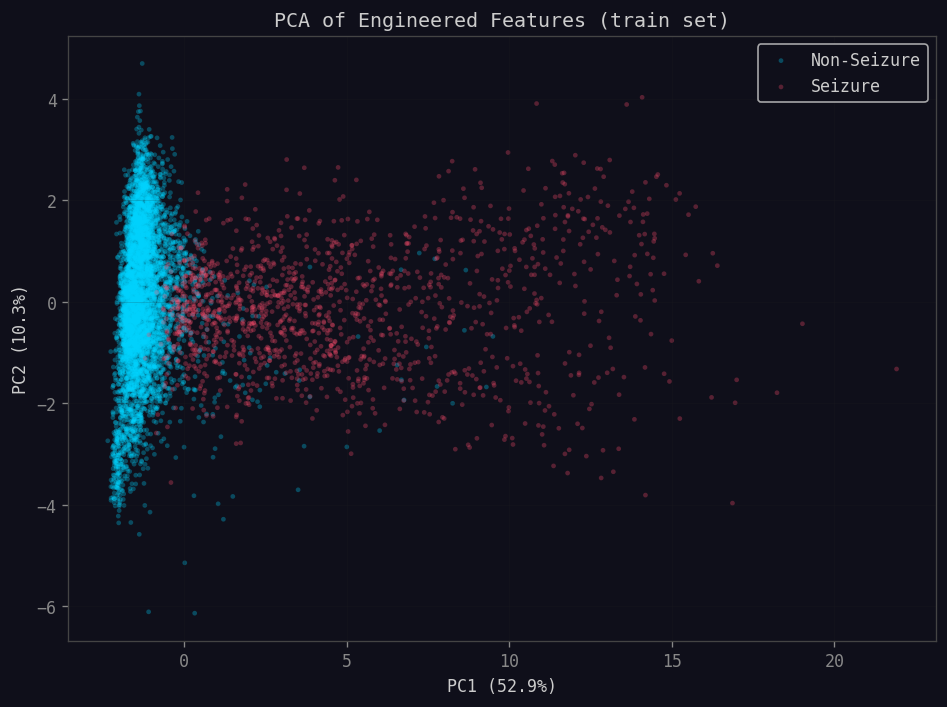

In [63]:
# -- 4.4 PCA for visualisation (NOT used in model training) --
pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_train)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, '
      f'PC2={pca.explained_variance_ratio_[1]:.2%}')

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0, PALETTE[0], 'Non-Seizure'), (1, PALETTE[1], 'Seizure')]:
    mask = y_train == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label,
               alpha=0.3, s=8, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA of Engineered Features (train set)', color='#ccc')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. From-Scratch Model Implementations

> **Note:** All classifiers are implemented using NumPy only -- no `sklearn.linear_model`,
> no PyTorch, no TensorFlow. sklearn is used only for metric helpers and data utilities.

### 5.1 Logistic Regression (Gradient Descent with L2 Regularisation)

In [64]:
class LogisticRegressionScratch:
    """
    Binary logistic regression trained with mini-batch gradient descent.
    Loss: weighted binary cross-entropy + L2 regularisation.
    """
    def __init__(self, lr=0.01, epochs=300, lam=0.01, batch_size=128, class_weight=None):
        self.lr           = lr
        self.epochs       = epochs
        self.lam          = lam
        self.batch_size   = batch_size
        self.class_weight = class_weight or {0: 1.0, 1: 1.0}
        self.w            = None
        self.b            = 0.0
        self.losses       = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _weighted_bce(self, y_true, y_pred, weights):
        eps = 1e-12
        return -np.mean(weights * (
            y_true * np.log(y_pred + eps) +
            (1 - y_true) * np.log(1 - y_pred + eps)
        ))

    def fit(self, X, y):
        N, D  = X.shape
        self.w = np.zeros(D)
        self.b = 0.0
        w_map  = np.where(y == 1, self.class_weight[1], self.class_weight[0])
        for epoch in range(self.epochs):
            idx  = np.random.permutation(N)
            X_s, y_s, w_s = X[idx], y[idx], w_map[idx]
            epoch_loss = 0.0
            for start in range(0, N, self.batch_size):
                Xb = X_s[start:start + self.batch_size]
                yb = y_s[start:start + self.batch_size]
                wb = w_s[start:start + self.batch_size]
                z  = Xb @ self.w + self.b
                p  = self._sigmoid(z)
                err    = wb * (p - yb)
                grad_w = Xb.T @ err / len(yb) + self.lam * self.w
                grad_b = err.mean()
                self.w -= self.lr * grad_w
                self.b -= self.lr * grad_b
                epoch_loss += self._weighted_bce(yb, p, wb)
            self.losses.append(epoch_loss)
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('LogisticRegressionScratch defined')

LogisticRegressionScratch defined


### 5.2 Linear Discriminant Analysis (LDA)

In [65]:
class LDAScratch:
    """
    Binary Linear Discriminant Analysis.
    Projects data onto Fisher's optimal discriminant direction.
    """
    def __init__(self, class_weight=None):
        self.class_weight = class_weight or {0: 1.0, 1: 1.0}

    def fit(self, X, y):
        classes = np.unique(y)
        D       = X.shape[1]
        means   = {}
        Sw      = np.zeros((D, D))
        for c in classes:
            Xc       = X[y == c]
            means[c] = Xc.mean(axis=0)
            Xc_c     = Xc - means[c]
            Sw      += self.class_weight[c] * (Xc_c.T @ Xc_c)
        self.mu0    = means[0]
        self.mu1    = means[1]
        Sw_inv      = np.linalg.pinv(Sw)
        self.w_lda  = Sw_inv @ (self.mu1 - self.mu0)
        self.w_lda /= np.linalg.norm(self.w_lda) + 1e-12
        proj0       = X[y == 0] @ self.w_lda
        proj1       = X[y == 1] @ self.w_lda
        self.thresh = (proj0.mean() + proj1.mean()) / 2.0
        return self

    def project(self, X):
        return X @ self.w_lda

    def predict_proba(self, X):
        proj = self.project(X)
        return 1.0 / (1.0 + np.exp(-(proj - self.thresh)))

    def predict(self, X):
        return (self.project(X) >= self.thresh).astype(int)

print('LDAScratch defined')

LDAScratch defined


### 5.3 Perceptron

In [66]:
class PerceptronScratch:
    """
    Binary Perceptron with weighted updates.
    Labels are internally converted to {-1, +1}.
    """
    def __init__(self, lr=0.01, epochs=100, class_weight=None):
        self.lr           = lr
        self.epochs       = epochs
        self.class_weight = class_weight or {0: 1.0, 1: 1.0}
        self.w            = None
        self.b            = 0.0
        self.errors_      = []

    def fit(self, X, y):
        N, D      = X.shape
        self.w    = np.zeros(D)
        self.b    = 0.0
        y_signed  = np.where(y == 1, 1.0, -1.0)
        cw_arr    = np.where(y == 1, self.class_weight[1], self.class_weight[0])
        for epoch in range(self.epochs):
            idx     = np.random.permutation(N)
            n_err   = 0
            for i in idx:
                pred = np.sign(self.w @ X[i] + self.b)
                if pred == 0: pred = 1.0
                if pred != y_signed[i]:
                    scale   = self.lr * cw_arr[i]
                    self.w += scale * y_signed[i] * X[i]
                    self.b += scale * y_signed[i]
                    n_err  += 1
            self.errors_.append(n_err)
            if n_err == 0:
                print(f'  Perceptron converged at epoch {epoch + 1}')
                break
        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict_proba(self, X):
        return 1.0 / (1.0 + np.exp(-self.decision_function(X)))

    def predict(self, X):
        return (self.decision_function(X) >= 0).astype(int)

print('PerceptronScratch defined')

PerceptronScratch defined


### 5.4 Kernel SVM (SMO Algorithm)

In [67]:
class KernelSVMScratch:
    """
    Binary SVM with RBF kernel, trained via simplified SMO (Platt 1998).
    """
    def __init__(self, C=1.0, gamma=0.1, tol=1e-3, max_passes=5,
                 class_weight=None, max_iter=10000):
        self.C            = C
        self.gamma        = gamma
        self.tol          = tol
        self.max_passes   = max_passes
        self.max_iter     = max_iter
        self.class_weight = class_weight or {0: 1.0, 1: 1.0}

    def _rbf(self, X1, X2):
        sq_dists = (
            np.sum(X1 ** 2, axis=1, keepdims=True) +
            np.sum(X2 ** 2, axis=1) -
            2 * X1 @ X2.T
        )
        return np.exp(-self.gamma * sq_dists)

    def fit(self, X, y):
        self.X_sv = X.copy()
        ypm       = np.where(y == 1, 1.0, -1.0)
        N         = X.shape[0]
        C_per     = np.where(y == 1,
                             self.C * self.class_weight[1],
                             self.C * self.class_weight[0])
        alpha  = np.zeros(N)
        b      = 0.0
        K      = self._rbf(X, X)
        passes = 0
        total_it = 0
        while passes < self.max_passes and total_it < self.max_iter:
            num_changed = 0
            for i in range(N):
                Ei = (alpha * ypm) @ K[i] + b - ypm[i]
                if ((ypm[i] * Ei < -self.tol and alpha[i] < C_per[i]) or
                        (ypm[i] * Ei > self.tol and alpha[i] > 0)):
                    j = np.random.randint(0, N - 1)
                    if j >= i: j += 1
                    Ej = (alpha * ypm) @ K[j] + b - ypm[j]
                    ai_old, aj_old = alpha[i], alpha[j]
                    if ypm[i] != ypm[j]:
                        L = max(0, alpha[j] - alpha[i])
                        H = min(C_per[j], C_per[j] - alpha[i] + alpha[j])
                    else:
                        L = max(0, alpha[i] + alpha[j] - C_per[j])
                        H = min(C_per[j], alpha[i] + alpha[j])
                    if L >= H: continue
                    eta = 2 * K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0: continue
                    alpha[j] -= ypm[j] * (Ei - Ej) / eta
                    alpha[j]  = np.clip(alpha[j], L, H)
                    if abs(alpha[j] - aj_old) < 1e-5: continue
                    alpha[i] += ypm[i] * ypm[j] * (aj_old - alpha[j])
                    b1 = b - Ei - ypm[i]*(alpha[i]-ai_old)*K[i,i] - ypm[j]*(alpha[j]-aj_old)*K[i,j]
                    b2 = b - Ej - ypm[i]*(alpha[i]-ai_old)*K[i,j] - ypm[j]*(alpha[j]-aj_old)*K[j,j]
                    if   0 < alpha[i] < C_per[i]: b = b1
                    elif 0 < alpha[j] < C_per[j]: b = b2
                    else: b = (b1 + b2) / 2
                    num_changed += 1
            total_it += 1
            passes = passes + 1 if num_changed == 0 else 0
        sv_mask          = alpha > 1e-5
        self.alpha_sv    = alpha[sv_mask]
        self.y_sv        = ypm[sv_mask]
        self.X_sv        = X[sv_mask]
        self.b           = b
        print(f'  SVM fit complete -- {sv_mask.sum()} SVs | {total_it} iterations')
        return self

    def _decision(self, X):
        K = self._rbf(X, self.X_sv)
        return K @ (self.alpha_sv * self.y_sv) + self.b

    def predict_proba(self, X):
        return 1.0 / (1.0 + np.exp(-self._decision(X)))

    def predict(self, X):
        return (self._decision(X) >= 0).astype(int)

print('KernelSVMScratch (SMO) defined')

KernelSVMScratch (SMO) defined


### 5.5 Multi-Layer Perceptron (MLP) with Backpropagation

In [68]:
class MLPScratch:
    """
    Fully-connected MLP with ReLU (hidden) + sigmoid output.
    Mini-batch SGD with momentum, L2 weight decay, early stopping.
    """
    def __init__(self, layer_sizes, lr=0.001, epochs=200,
                 lam=1e-4, batch_size=64, momentum=0.9,
                 patience=15, class_weight=None):
        self.layer_sizes  = layer_sizes
        self.lr           = lr
        self.epochs       = epochs
        self.lam          = lam
        self.batch_size   = batch_size
        self.momentum     = momentum
        self.patience     = patience
        self.class_weight = class_weight or {0: 1.0, 1: 1.0}
        self.weights      = []
        self.biases       = []
        self.train_losses = []
        self.val_losses   = []

    def _init_weights(self):
        self.weights, self.biases = [], []
        self.vw, self.vb          = [], []
        for i in range(len(self.layer_sizes) - 1):
            fan_in  = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            b = np.zeros(fan_out)
            self.weights.append(W)
            self.biases.append(b)
            self.vw.append(np.zeros_like(W))
            self.vb.append(np.zeros_like(b))

    @staticmethod
    def _relu(z):      return np.maximum(0, z)
    @staticmethod
    def _relu_grad(z): return (z > 0).astype(float)
    @staticmethod
    def _sigmoid(z):   return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _forward(self, X):
        activations, zs = [X], []
        A = X
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            Z = A @ W + b
            zs.append(Z)
            A = self._sigmoid(Z) if i == len(self.weights) - 1 else self._relu(Z)
            activations.append(A)
        return activations, zs

    def _bce_loss(self, y_true, y_pred, sample_w):
        eps = 1e-12
        return -np.mean(sample_w * (
            y_true * np.log(y_pred + eps) +
            (1 - y_true) * np.log(1 - y_pred + eps)
        ))

    def _backward(self, activations, zs, y_batch, sw_batch):
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)
        n       = len(y_batch)
        delta   = sw_batch[:, None] * (activations[-1] - y_batch[:, None]) / n
        for i in reversed(range(len(self.weights))):
            grads_w[i] = activations[i].T @ delta + self.lam * self.weights[i]
            grads_b[i] = delta.sum(axis=0)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self._relu_grad(zs[i - 1])
        return grads_w, grads_b

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        self._init_weights()
        N        = X_train.shape[0]
        sw_train = np.where(y_train == 1, self.class_weight[1], self.class_weight[0])
        best_val_loss = np.inf
        patience_cnt  = 0
        best_w        = None
        for epoch in range(self.epochs):
            idx = np.random.permutation(N)
            for start in range(0, N, self.batch_size):
                b_idx       = idx[start:start + self.batch_size]
                Xb, yb, swb = X_train[b_idx], y_train[b_idx], sw_train[b_idx]
                acts, zs    = self._forward(Xb)
                gw, gb      = self._backward(acts, zs, yb, swb)
                for i in range(len(self.weights)):
                    self.vw[i]       = self.momentum * self.vw[i] - self.lr * gw[i]
                    self.vb[i]       = self.momentum * self.vb[i] - self.lr * gb[i]
                    self.weights[i] += self.vw[i]
                    self.biases[i]  += self.vb[i]
            tr_pred = self._forward(X_train)[0][-1].ravel()
            tl      = self._bce_loss(y_train, tr_pred, sw_train)
            self.train_losses.append(tl)
            if X_val is not None:
                sw_val  = np.where(y_val == 1, self.class_weight[1], self.class_weight[0])
                vl_pred = self._forward(X_val)[0][-1].ravel()
                vl      = self._bce_loss(y_val, vl_pred, sw_val)
                self.val_losses.append(vl)
                if vl < best_val_loss - 1e-4:
                    best_val_loss = vl
                    best_w        = ([w.copy() for w in self.weights],
                                     [b.copy() for b in self.biases])
                    patience_cnt  = 0
                else:
                    patience_cnt += 1
                if patience_cnt >= self.patience:
                    print(f'  Early stopping at epoch {epoch+1}')
                    break
        if best_w is not None:
            self.weights, self.biases = best_w
        return self

    def predict_proba(self, X):
        return self._forward(X)[0][-1].ravel()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('MLPScratch (backprop + early stopping) defined')

MLPScratch (backprop + early stopping) defined


## 6. Model Training and Hyperparameter Tuning (Validation Set)

All hyperparameter decisions are made on the **validation set** -- the test set is touched exactly once at the end.

In [69]:
# -- Helper: evaluate on a split --
def evaluate(model, X, y, name='', threshold=0.5):
    p     = model.predict_proba(X)
    preds = (p >= threshold).astype(int)
    acc   = accuracy_score(y, preds)
    f1    = f1_score(y, preds, zero_division=0)
    auc   = roc_auc_score(y, p)
    if name:
        print(f'{name:30s} Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    return dict(acc=acc, f1=f1, auc=auc, proba=p, preds=preds)

results = {}

### 6.1 Logistic Regression -- Regularisation Sweep

In [70]:
print('=== Logistic Regression -- Validation Sweep ===')
best_lr_model, best_lr_f1, best_lam = None, 0, 0
lam_grid = [0.0001, 0.001, 0.01, 0.1, 1.0]

for lam in lam_grid:
    m = LogisticRegressionScratch(lr=0.05, epochs=200, lam=lam,
                                   batch_size=256, class_weight=CLASS_WEIGHT)
    m.fit(X_train, y_train)
    res = evaluate(m, X_val, y_val, name=f'  lambda={lam}')
    if res['f1'] > best_lr_f1:
        best_lr_f1, best_lr_model, best_lam = res['f1'], m, lam

print(f'\nBest lambda = {best_lam} | Val F1 = {best_lr_f1:.4f}')
results['Logistic Regression'] = evaluate(best_lr_model, X_test, y_test, name='TEST LR')

=== Logistic Regression -- Validation Sweep ===
  lambda=0.0001                Acc=0.9630  F1=0.9112  AUC=0.9936
  lambda=0.001                 Acc=0.9635  F1=0.9121  AUC=0.9936
  lambda=0.01                  Acc=0.9630  F1=0.9108  AUC=0.9930
  lambda=0.1                   Acc=0.9622  F1=0.9061  AUC=0.9915
  lambda=1.0                   Acc=0.9517  F1=0.8723  AUC=0.9909

Best lambda = 0.001 | Val F1 = 0.9121
TEST LR                        Acc=0.9648  F1=0.9152  AUC=0.9899


### 6.2 LDA

In [71]:
print('=== LDA ===')
lda_model = LDAScratch(class_weight=CLASS_WEIGHT)
lda_model.fit(X_train, y_train)
evaluate(lda_model, X_val, y_val, name='LDA (val)')
results['LDA'] = evaluate(lda_model, X_test, y_test, name='TEST LDA')

=== LDA ===
LDA (val)                      Acc=0.9648  F1=0.9126  AUC=0.9916
TEST LDA                       Acc=0.9609  F1=0.9026  AUC=0.9898


### 6.3 Perceptron -- Learning Rate Sweep

In [72]:
print('=== Perceptron -- Validation Sweep ===')
best_perc, best_perc_f1, best_lr_p = None, 0, 0
lr_p_grid = [0.0001, 0.001, 0.01, 0.1]

for lr_p in lr_p_grid:
    m = PerceptronScratch(lr=lr_p, epochs=100, class_weight=CLASS_WEIGHT)
    m.fit(X_train, y_train)
    res = evaluate(m, X_val, y_val, name=f'  lr={lr_p}')
    if res['f1'] > best_perc_f1:
        best_perc_f1, best_perc, best_lr_p = res['f1'], m, lr_p

print(f'\nBest lr = {best_lr_p} | Val F1 = {best_perc_f1:.4f}')
results['Perceptron'] = evaluate(best_perc, X_test, y_test, name='TEST Perceptron')

=== Perceptron -- Validation Sweep ===
  lr=0.0001                    Acc=0.9652  F1=0.9180  AUC=0.9951
  lr=0.001                     Acc=0.9109  F1=0.8128  AUC=0.9855
  lr=0.01                      Acc=0.9552  F1=0.8956  AUC=0.9936
  lr=0.1                       Acc=0.9622  F1=0.9117  AUC=0.9941

Best lr = 0.0001 | Val F1 = 0.9180
TEST Perceptron                Acc=0.9604  F1=0.9085  AUC=0.9941


### 6.4 Kernel SVM -- C and gamma Grid Search

In [73]:
print('=== Kernel SVM -- Validation Sweep (subsampled) ===')
sub_size = 1500
sub_idx  = np.concatenate([
    np.random.choice(np.where(y_train == 0)[0], sub_size // 2, replace=False),
    np.random.choice(np.where(y_train == 1)[0], sub_size // 2, replace=False)
])
X_sub, y_sub = X_train[sub_idx], y_train[sub_idx]

C_grid     = [0.1, 1.0, 5.0, 10.0]
gamma_grid = [0.01, 0.05, 0.1, 0.5]
best_svm, best_svm_f1, best_C, best_gamma = None, 0, 0, 0

for C in C_grid:
    for g in gamma_grid:
        print(f'  Training SVM C={C}, gamma={g}...', end=' ', flush=True)
        start_t = time.time()
        m = KernelSVMScratch(C=C, gamma=g, max_passes=3,
                              class_weight=CLASS_WEIGHT, max_iter=200)
        m.fit(X_sub, y_sub)
        res = evaluate(m, X_val, y_val)
        dt  = time.time() - start_t
        print(f'F1={res["f1"]:.4f} ({dt:.1f}s)')
        if res['f1'] > best_svm_f1:
            best_svm_f1, best_C, best_gamma = res['f1'], C, g

print(f'\nBest C={best_C}, gamma={best_gamma} | Val F1={best_svm_f1:.4f}')
print('Retraining best SVM on full train set...')
best_svm = KernelSVMScratch(C=best_C, gamma=best_gamma, max_passes=5,
                              class_weight=CLASS_WEIGHT, max_iter=500)
best_svm.fit(X_train, y_train)
results['Kernel SVM (RBF)'] = evaluate(best_svm, X_test, y_test, name='TEST SVM')

=== Kernel SVM -- Validation Sweep (subsampled) ===
  Training SVM C=0.1, gamma=0.01...   SVM fit complete -- 416 SVs | 200 iterations
F1=0.8999 (1.8s)
  Training SVM C=0.1, gamma=0.05...   SVM fit complete -- 411 SVs | 200 iterations
F1=0.9069 (1.9s)
  Training SVM C=0.1, gamma=0.1...   SVM fit complete -- 508 SVs | 200 iterations
F1=0.8973 (2.1s)
  Training SVM C=0.1, gamma=0.5...   SVM fit complete -- 953 SVs | 200 iterations
F1=0.8394 (2.7s)
  Training SVM C=1.0, gamma=0.01...   SVM fit complete -- 303 SVs | 200 iterations
F1=0.8787 (1.6s)
  Training SVM C=1.0, gamma=0.05...   SVM fit complete -- 318 SVs | 200 iterations
F1=0.9173 (1.8s)
  Training SVM C=1.0, gamma=0.1...   SVM fit complete -- 411 SVs | 200 iterations
F1=0.8928 (2.0s)
  Training SVM C=1.0, gamma=0.5...   SVM fit complete -- 816 SVs | 200 iterations
F1=0.8771 (3.3s)
  Training SVM C=5.0, gamma=0.01...   SVM fit complete -- 280 SVs | 200 iterations
F1=0.9135 (1.7s)
  Training SVM C=5.0, gamma=0.05...   SVM fit comple

### 6.5 MLP -- Hidden Layer Architecture Search

In [74]:
print('=== MLP -- Validation Sweep ===')
D         = X_train.shape[1]
arch_grid = [[D, 32, 1], [D, 64, 32, 1], [D, 128, 64, 1]]
best_mlp, best_mlp_f1, best_arch = None, 0, None

for arch in arch_grid:
    m = MLPScratch(layer_sizes=arch, lr=0.001, epochs=200, lam=1e-4,
                   batch_size=64, momentum=0.9, patience=15,
                   class_weight=CLASS_WEIGHT)
    m.fit(X_train, y_train, X_val=X_val, y_val=y_val)
    res = evaluate(m, X_val, y_val, name=f'  arch={arch}')
    if res['f1'] > best_mlp_f1:
        best_mlp_f1, best_mlp, best_arch = res['f1'], m, arch

print(f'\nBest arch={best_arch} | Val F1={best_mlp_f1:.4f}')
results['MLP'] = evaluate(best_mlp, X_test, y_test, name='TEST MLP')

=== MLP -- Validation Sweep ===
  arch=[19, 32, 1]             Acc=0.9722  F1=0.9333  AUC=0.9971
  Early stopping at epoch 145
  arch=[19, 64, 32, 1]         Acc=0.9735  F1=0.9361  AUC=0.9970
  Early stopping at epoch 119
  arch=[19, 128, 64, 1]        Acc=0.9752  F1=0.9401  AUC=0.9972

Best arch=[19, 128, 64, 1] | Val F1=0.9401
TEST MLP                       Acc=0.9796  F1=0.9506  AUC=0.9977


## 7. 5-Fold Stratified Cross-Validation (Best Models)

In [75]:
X_trainval_sc    = scaler.fit_transform(np.vstack([X_train, X_val]))
y_trainval_all   = np.concatenate([y_train, y_val])
skf              = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results       = {'LR': [], 'LDA': [], 'Perceptron': [], 'MLP': []}

print('5-Fold CV (F1 per fold)')
print('-' * 65)

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_trainval_sc, y_trainval_all)):
    Xtr, Xvl = X_trainval_sc[tr_idx], X_trainval_sc[vl_idx]
    ytr, yvl = y_trainval_all[tr_idx], y_trainval_all[vl_idx]
    scaler_fold = StandardScaler().fit(Xtr)
    Xtr = scaler_fold.transform(Xtr)
    Xvl = scaler_fold.transform(Xvl)
    cw  = {0: w_neg, 1: w_pos}

    lr_cv = LogisticRegressionScratch(lr=0.05, epochs=200, lam=best_lam,
                                       batch_size=256, class_weight=cw).fit(Xtr, ytr)
    cv_results['LR'].append(evaluate(lr_cv, Xvl, yvl))

    lda_cv = LDAScratch(class_weight=cw).fit(Xtr, ytr)
    cv_results['LDA'].append(evaluate(lda_cv, Xvl, yvl))

    perc_cv = PerceptronScratch(lr=best_lr_p, epochs=100, class_weight=cw).fit(Xtr, ytr)
    cv_results['Perceptron'].append(evaluate(perc_cv, Xvl, yvl))

    mlp_cv = MLPScratch(layer_sizes=best_arch, lr=0.001, epochs=150, lam=1e-4,
                         batch_size=64, momentum=0.9, patience=10,
                         class_weight=cw).fit(Xtr, ytr, X_val=Xvl, y_val=yvl)
    cv_results['MLP'].append(evaluate(mlp_cv, Xvl, yvl))

    lr_r   = cv_results['LR'][-1]
    lda_r  = cv_results['LDA'][-1]
    perc_r = cv_results['Perceptron'][-1]
    mlp_r  = cv_results['MLP'][-1]
    print(f'Fold {fold+1}: LR {lr_r["f1"]:.3f} | LDA {lda_r["f1"]:.3f} | '
          f'Perceptron {perc_r["f1"]:.3f} | MLP {mlp_r["f1"]:.3f}')

print('\n--- Mean +/- Std (F1) ---')
for name, fold_res in cv_results.items():
    f1s = [r['f1'] for r in fold_res]
    print(f'{name:12s}: {np.mean(f1s):.4f} +/- {np.std(f1s):.4f}')

5-Fold CV (F1 per fold)
-----------------------------------------------------------------
  Early stopping at epoch 84
Fold 1: LR 0.917 | LDA 0.912 | Perceptron 0.909 | MLP 0.937
  Early stopping at epoch 103
Fold 2: LR 0.915 | LDA 0.905 | Perceptron 0.854 | MLP 0.936
  Early stopping at epoch 70
Fold 3: LR 0.917 | LDA 0.907 | Perceptron 0.891 | MLP 0.945
  Early stopping at epoch 80
Fold 4: LR 0.936 | LDA 0.929 | Perceptron 0.878 | MLP 0.950
  Early stopping at epoch 102
Fold 5: LR 0.918 | LDA 0.916 | Perceptron 0.901 | MLP 0.941

--- Mean +/- Std (F1) ---
LR          : 0.9206 +/- 0.0078
LDA         : 0.9137 +/- 0.0087
Perceptron  : 0.8865 +/- 0.0194
MLP         : 0.9418 +/- 0.0052


## 8. Results and Analysis

### 8.1 Final Test Results Table

In [76]:
rows = []
for model_name, res in results.items():
    rows.append({'Model':         model_name,
                 'Test Accuracy': f"{res['acc']:.4f}",
                 'Test F1':       f"{res['f1']:.4f}",
                 'Test AUC':      f"{res['auc']:.4f}"})
results_df = pd.DataFrame(rows).set_index('Model')
print('\n========== FINAL TEST RESULTS ==========')
display(results_df)


========== FINAL TEST RESULTS ==========


,Test Accuracy,Test F1,Test AUC
Model,,,
Logistic Regression,0.9648,0.9152,0.9899
LDA,0.9609,0.9026,0.9898
Perceptron,0.9604,0.9085,0.9941
Kernel SVM (RBF),0.9778,0.9458,0.9962
MLP,0.9796,0.9506,0.9977


### 8.2 ROC Curves

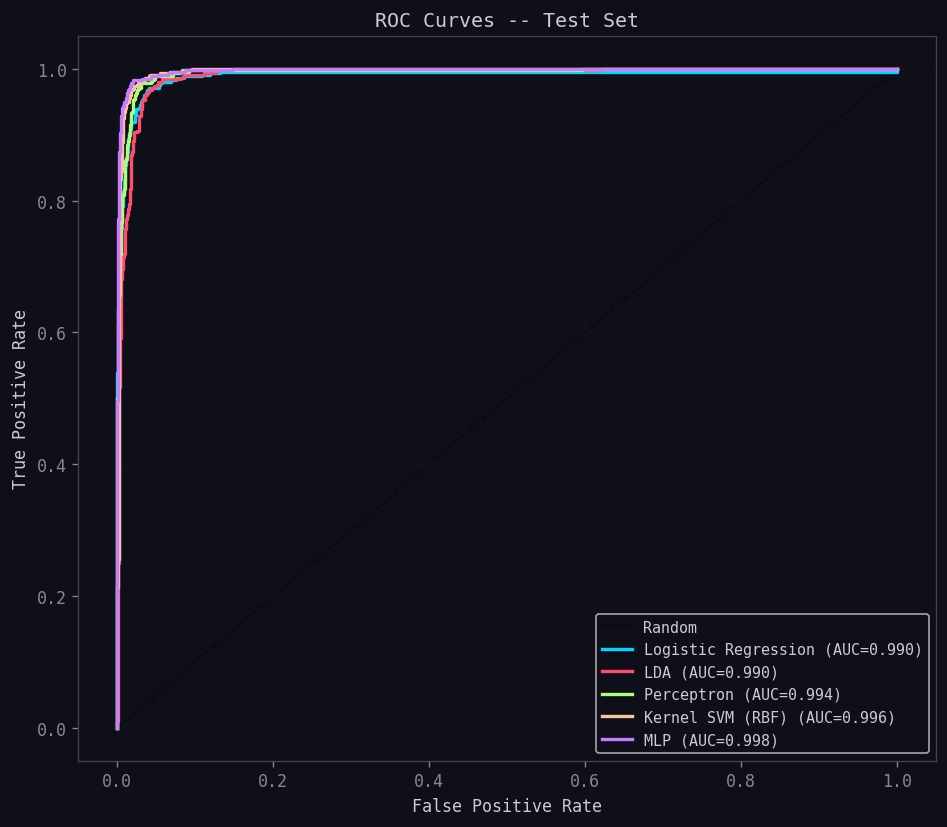

In [77]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1, label='Random')
for (name, res), color in zip(results.items(), PALETTE):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['auc']:.3f})")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves -- Test Set', color='#ccc')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 8.3 Confusion Matrices

Logistic Regression: TP=437  FP=58  FN=23  TN=1782  Recall=0.950  Precision=0.883
LDA: TP=417  FP=47  FN=43  TN=1793  Recall=0.907  Precision=0.899
Perceptron: TP=452  FP=83  FN=8  TN=1757  Recall=0.983  Precision=0.845
Kernel SVM (RBF): TP=445  FP=36  FN=15  TN=1804  Recall=0.967  Precision=0.925
MLP: TP=452  FP=39  FN=8  TN=1801  Recall=0.983  Precision=0.921


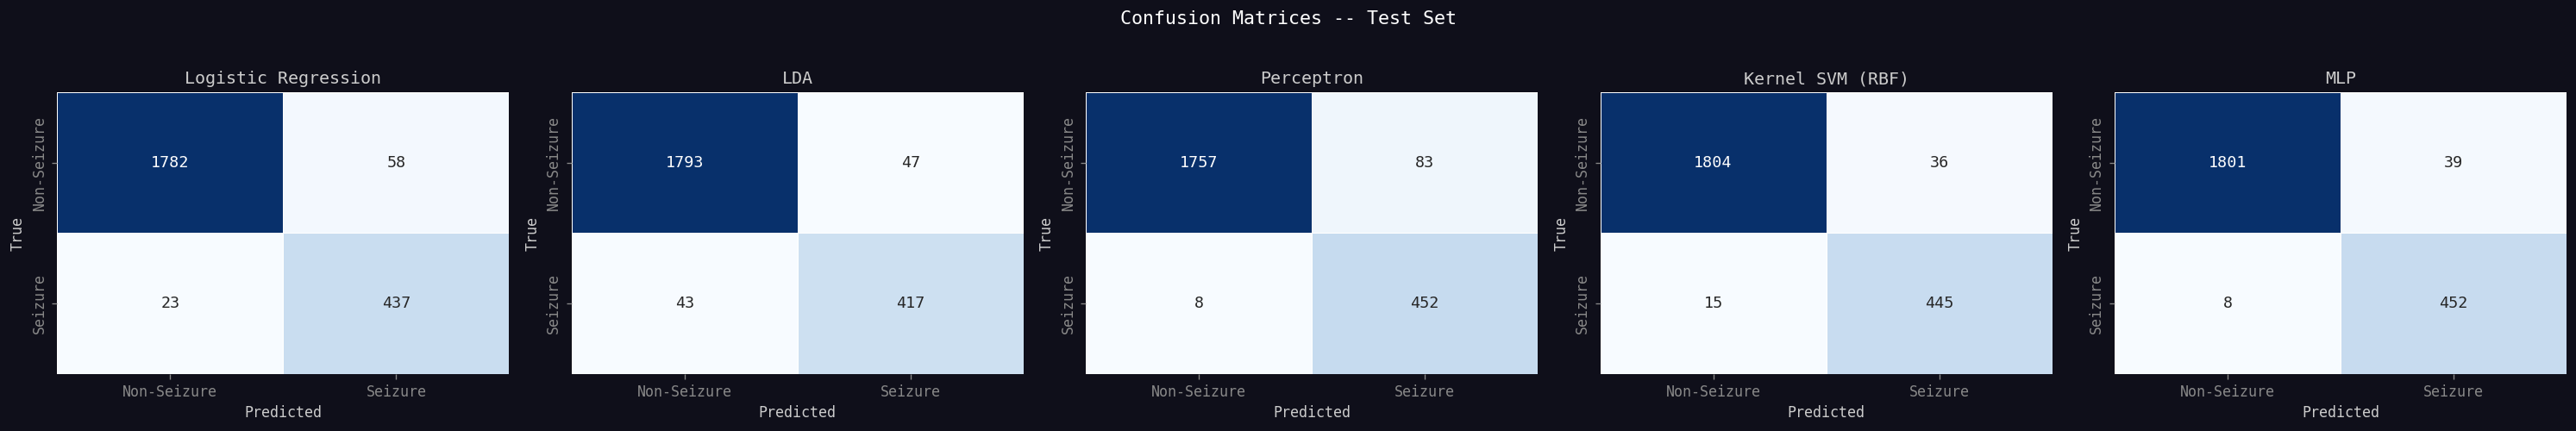

In [78]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1: axes = [axes]
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Seizure', 'Seizure'],
                yticklabels=['Non-Seizure', 'Seizure'],
                linewidths=0.5, cbar=False, annot_kws={'size': 11})
    ax.set_title(name, color='#ccc')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    tn, fp, fn, tp = cm.ravel()
    print(f'{name}: TP={tp}  FP={fp}  FN={fn}  TN={tn}  '
          f'Recall={tp/(tp+fn):.3f}  Precision={tp/(tp+fp):.3f}')
plt.suptitle('Confusion Matrices -- Test Set', fontsize=13, color='#fff', y=1.03)
plt.tight_layout()
plt.show()

### 8.4 MLP Training and Validation Loss Curves

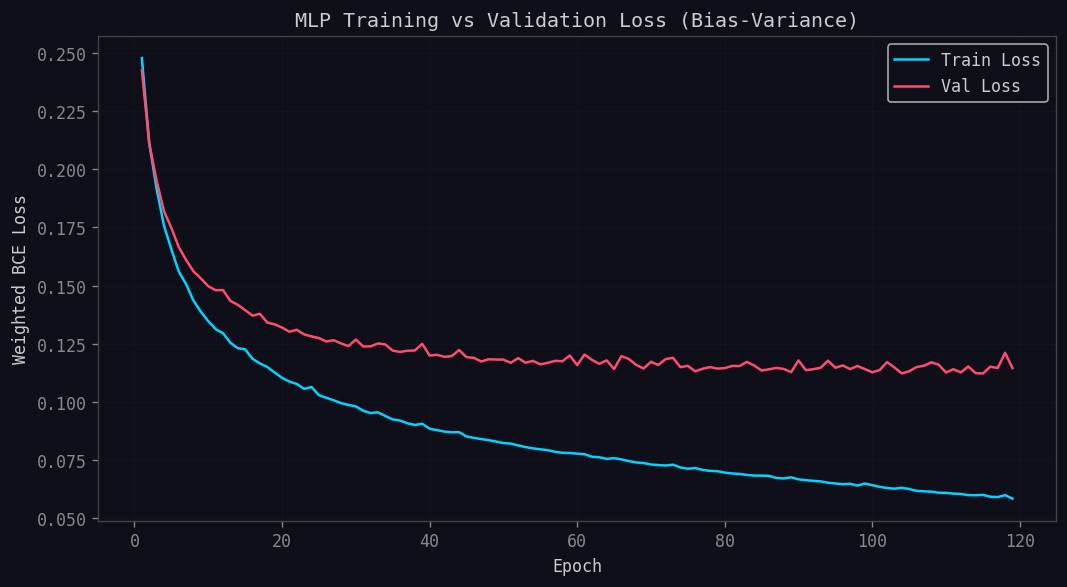

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs_ran = len(best_mlp.train_losses)
ax.plot(range(1, epochs_ran + 1), best_mlp.train_losses,
        color=PALETTE[0], lw=1.5, label='Train Loss')
if best_mlp.val_losses:
    ax.plot(range(1, len(best_mlp.val_losses) + 1), best_mlp.val_losses,
            color=PALETTE[1], lw=1.5, label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted BCE Loss')
ax.set_title('MLP Training vs Validation Loss (Bias-Variance)', color='#ccc')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.5 LR Training Loss Curve

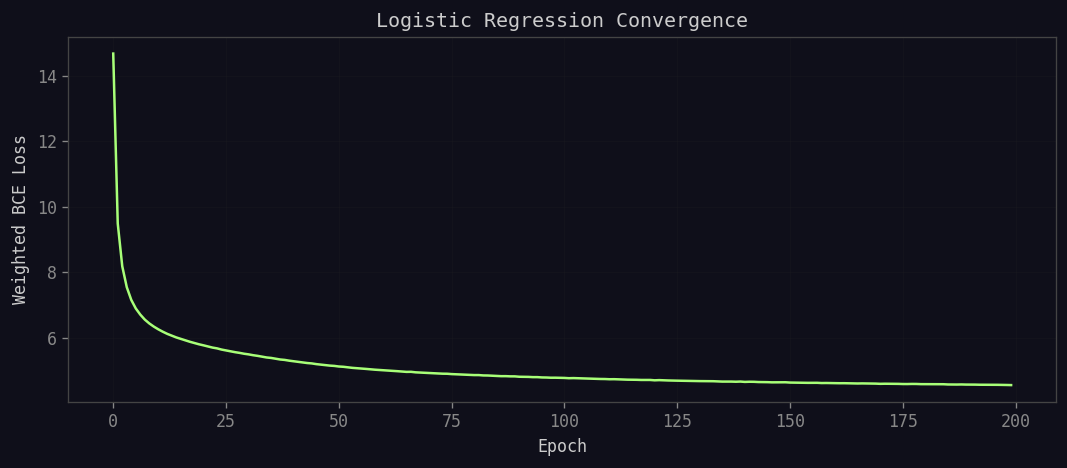

In [80]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(best_lr_model.losses, color=PALETTE[2], lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted BCE Loss')
ax.set_title('Logistic Regression Convergence', color='#ccc')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.6 Feature Importance (LR Weight Magnitude)

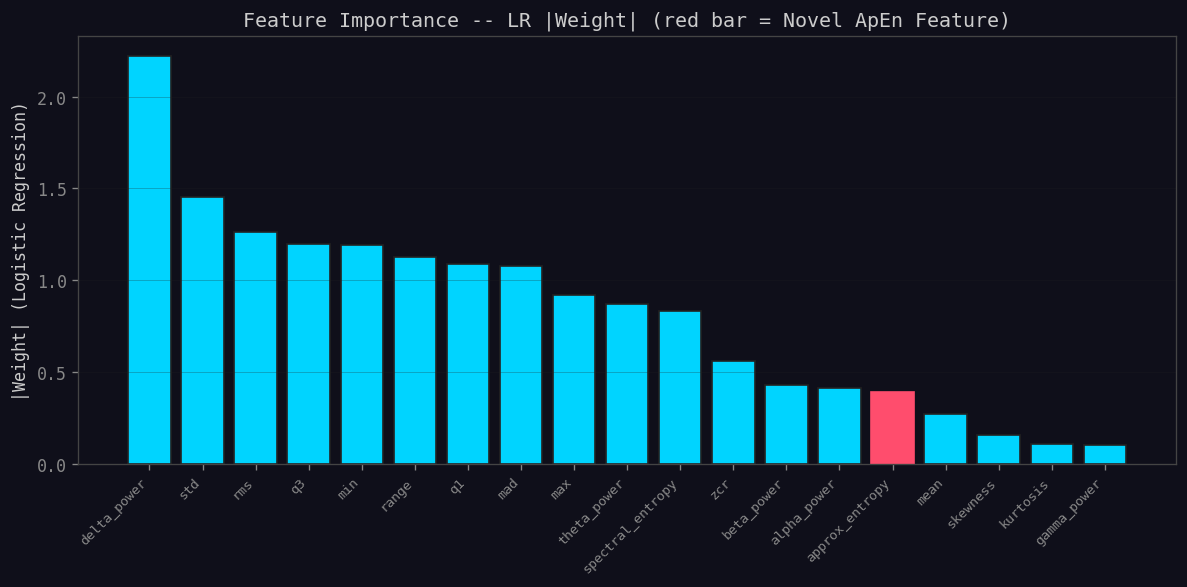

In [81]:
lr_importance = np.abs(best_lr_model.w)
sorted_idx    = np.argsort(lr_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(FEATURE_NAMES)), lr_importance[sorted_idx],
              color=PALETTE[0], edgecolor='#222')
bars[list(sorted_idx).index(FEATURE_NAMES.index('approx_entropy'))].set_color(PALETTE[1])
ax.set_xticks(range(len(FEATURE_NAMES)))
ax.set_xticklabels([FEATURE_NAMES[i] for i in sorted_idx],
                    rotation=45, ha='right', fontsize=8)
ax.set_ylabel('|Weight| (Logistic Regression)')
ax.set_title('Feature Importance -- LR |Weight| (red bar = Novel ApEn Feature)', color='#ccc')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Novel Analysis: LDA Projection and Phase-Space Visualisation

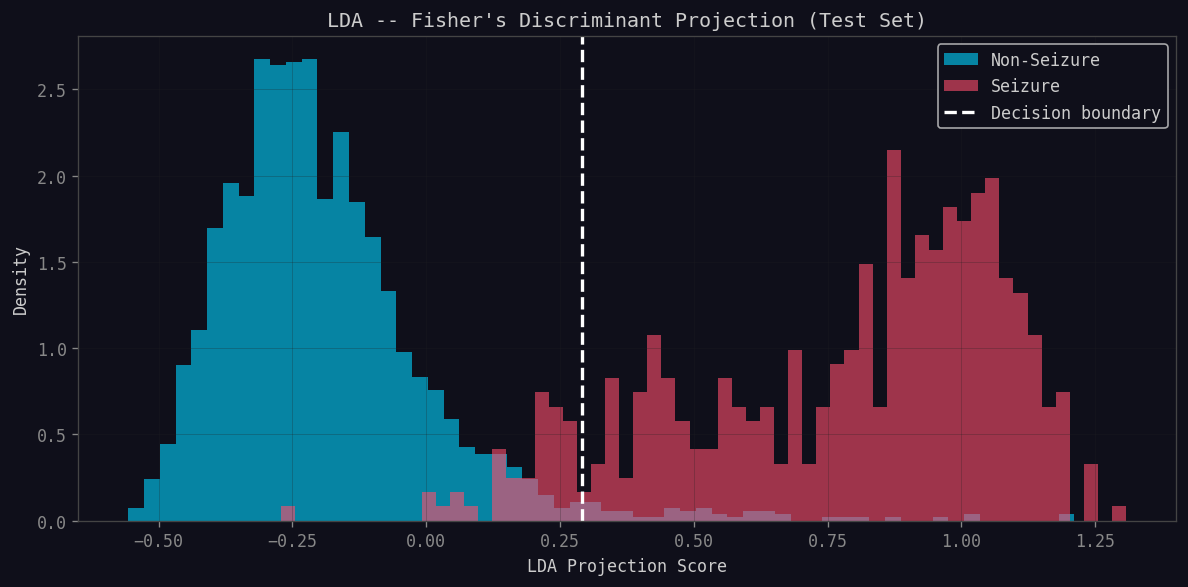

In [82]:
# -- 9.1 LDA discriminant projection histogram --
proj_test = lda_model.project(X_test)
fig, ax   = plt.subplots(figsize=(10, 5))
for cls, color, label in [(0, PALETTE[0], 'Non-Seizure'), (1, PALETTE[1], 'Seizure')]:
    vals = proj_test[y_test == cls]
    ax.hist(vals, bins=60, alpha=0.6, color=color, label=label, density=True)
ax.axvline(lda_model.thresh, color='white', lw=2, ls='--', label='Decision boundary')
ax.set_xlabel('LDA Projection Score')
ax.set_ylabel('Density')
ax.set_title("LDA -- Fisher's Discriminant Projection (Test Set)", color='#ccc')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

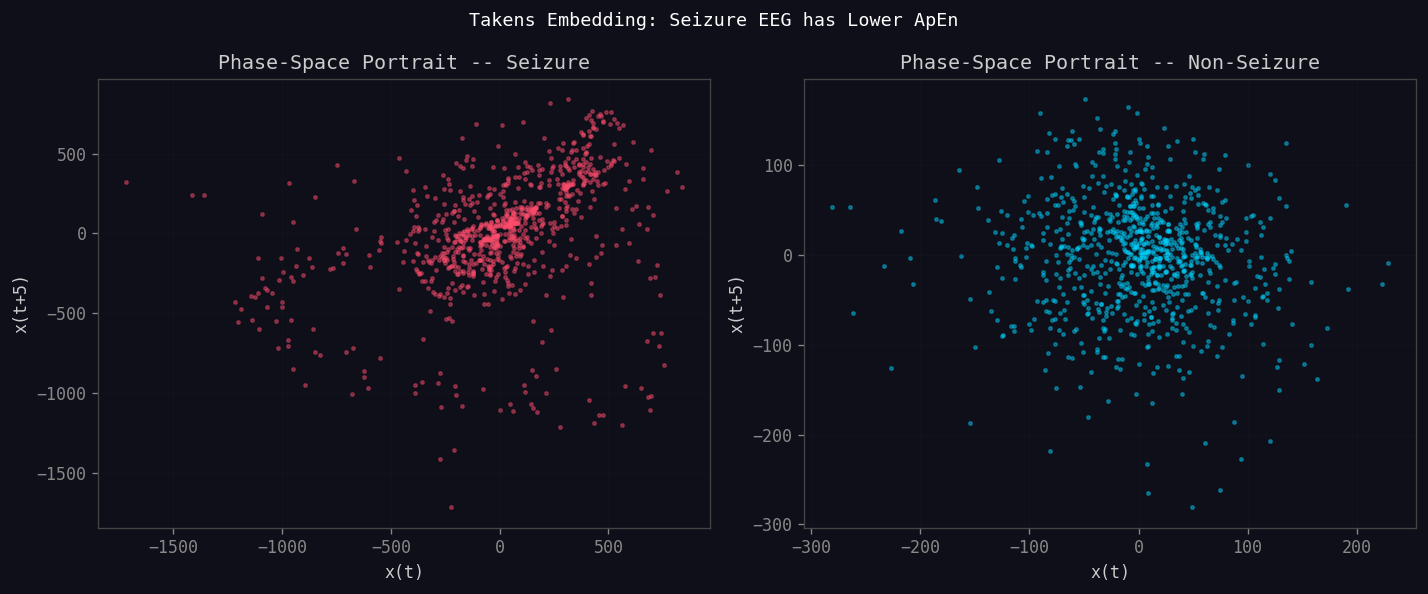

In [83]:
# -- 9.2 Phase-space (Takens) portrait --
TAU = 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cls, color, label in [
    (axes[0], 1, PALETTE[1], 'Seizure'),
    (axes[1], 0, PALETTE[0], 'Non-Seizure')
]:
    idxs = np.where(y_multi == (1 if cls == 1 else 4))[0][:5]
    for idx in idxs:
        sig = X[idx]
        ax.scatter(sig[:-TAU], sig[TAU:], s=4, alpha=0.4, color=color)
    ax.set_xlabel('x(t)')
    ax.set_ylabel(f'x(t+{TAU})')
    ax.set_title(f'Phase-Space Portrait -- {label}', color='#ccc')
    ax.grid(True, alpha=0.2)
plt.suptitle('Takens Embedding: Seizure EEG has Lower ApEn', fontsize=11, color='#fff')
plt.tight_layout()
plt.show()

## 10. Precision-Recall Curves and Threshold Tuning

Under class imbalance, PR curves are more informative than ROC curves.
We tune the decision threshold on the **validation set** by maximising F1 for each model.

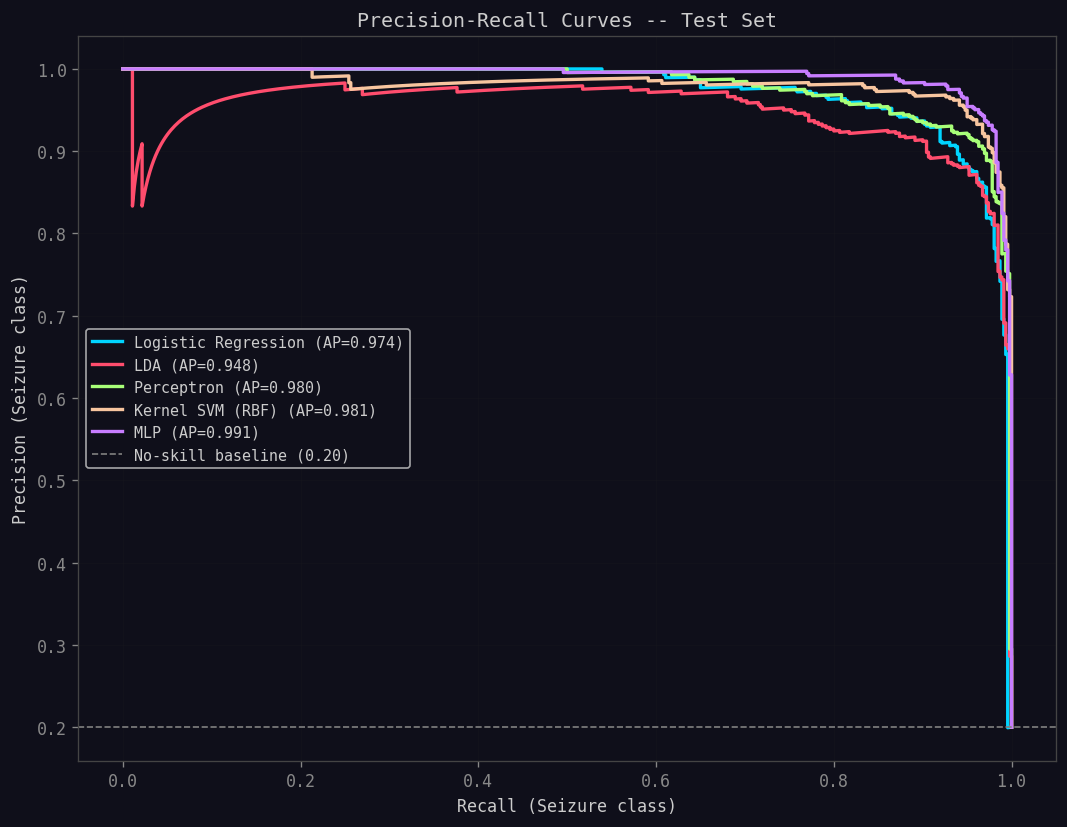

In [84]:
# -- PR curves on test set --
fig, ax = plt.subplots(figsize=(9, 7))
for (name, res), color in zip(results.items(), PALETTE):
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    ap = average_precision_score(y_test, res['proba'])
    ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

no_skill = y_test.sum() / len(y_test)
ax.axhline(no_skill, color='gray', lw=1, ls='--', label=f'No-skill baseline ({no_skill:.2f})')
ax.set_xlabel('Recall (Seizure class)')
ax.set_ylabel('Precision (Seizure class)')
ax.set_title('Precision-Recall Curves -- Test Set', color='#ccc')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [85]:
# -- Threshold tuning on validation set --
val_probas = {
    'Logistic Regression': best_lr_model.predict_proba(X_val),
    'LDA':                 lda_model.predict_proba(X_val),
    'Perceptron':          best_perc.predict_proba(X_val),
    'Kernel SVM (RBF)':    best_svm.predict_proba(X_val),
    'MLP':                 best_mlp.predict_proba(X_val),
}

print(f'{"Model":<25} {"Default F1":>12} {"Tuned Thresh":>14} {"Tuned F1":>10} {"Delta F1":>10}')
print('-' * 75)

tuned_results = {}
for name, val_p in val_probas.items():
    thresholds  = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    best_f1_val = 0.0
    for t in thresholds:
        preds = (val_p >= t).astype(int)
        f1    = f1_score(y_val, preds, zero_division=0)
        if f1 > best_f1_val:
            best_f1_val = f1
            best_thresh = t
    test_p      = results[name]['proba']
    default_f1  = results[name]['f1']
    tuned_preds = (test_p >= best_thresh).astype(int)
    tuned_f1    = f1_score(y_test, tuned_preds, zero_division=0)
    tuned_acc   = accuracy_score(y_test, tuned_preds)
    tuned_auc   = roc_auc_score(y_test, test_p)
    delta       = tuned_f1 - default_f1
    tuned_results[name] = dict(acc=tuned_acc, f1=tuned_f1, auc=tuned_auc,
                                thresh=best_thresh, preds=tuned_preds, proba=test_p)
    print(f'{name:<25} {default_f1:>12.4f} {best_thresh:>14.2f} {tuned_f1:>10.4f} {delta:>+10.4f}')

Model                       Default F1   Tuned Thresh   Tuned F1   Delta F1
---------------------------------------------------------------------------
Logistic Regression             0.9152           0.66     0.9234    +0.0082
LDA                             0.9026           0.50     0.9026    +0.0000
Perceptron                      0.9085           0.50     0.9085    +0.0000
Kernel SVM (RBF)                0.9458           0.49     0.9440    -0.0018
MLP                             0.9506           0.87     0.9560    +0.0055


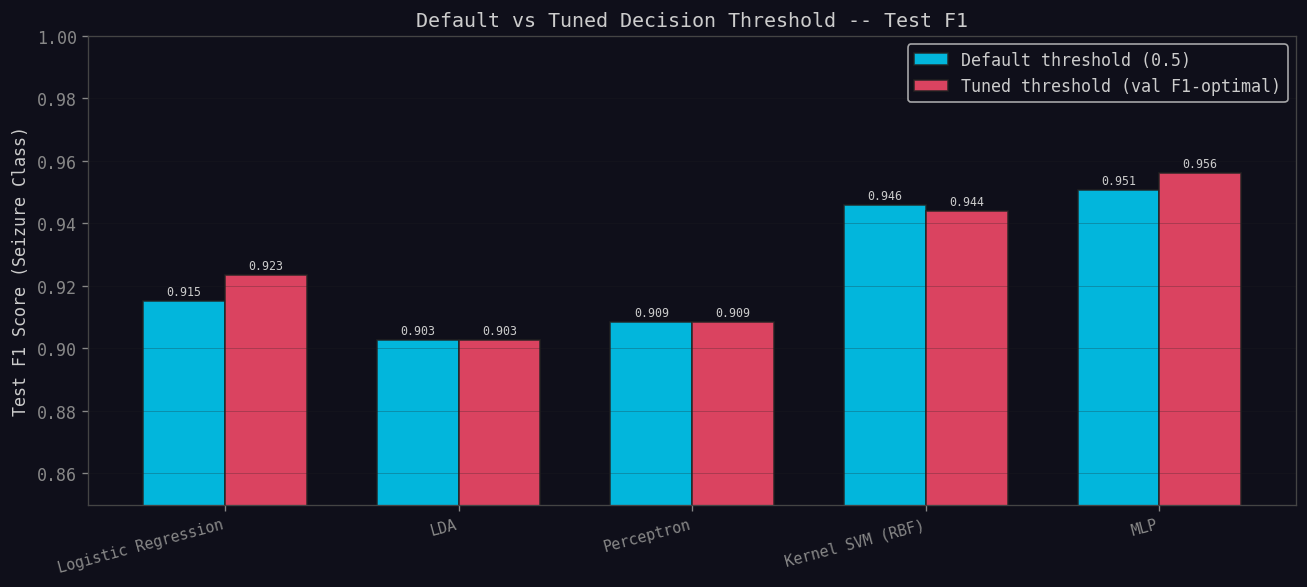

In [86]:
# -- Default vs tuned F1 bar chart --
model_names = list(tuned_results.keys())
default_f1s = [results[m]['f1']       for m in model_names]
tuned_f1s   = [tuned_results[m]['f1'] for m in model_names]
x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, default_f1s, width, label='Default threshold (0.5)',
               color=PALETTE[0], alpha=0.85, edgecolor='#222')
bars2 = ax.bar(x + width/2, tuned_f1s,   width, label='Tuned threshold (val F1-optimal)',
               color=PALETTE[1], alpha=0.85, edgecolor='#222')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Test F1 Score (Seizure Class)')
ax.set_title('Default vs Tuned Decision Threshold -- Test F1', color='#ccc')
ax.set_ylim(0.85, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, color='#ccc')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, color='#ccc')
plt.tight_layout()
plt.show()

## 11. Error Analysis

We investigate which samples are misclassified by the best model (SVM) to understand failure modes.

In [87]:
# -- Identify misclassified samples --
best_model_name = 'Kernel SVM (RBF)'
best_res        = results[best_model_name]
preds_best      = best_res['preds']
proba_best      = best_res['proba']

_, test_idx = train_test_split(
    np.arange(len(X_feat)), test_size=0.20, stratify=y, random_state=SEED)
y_multi_test = y_multi[test_idx]

fn_mask = (y_test == 1) & (preds_best == 0)
fp_mask = (y_test == 0) & (preds_best == 1)
correct = preds_best == y_test

print(f'Total test samples : {len(y_test)}')
print(f'False Negatives    : {fn_mask.sum()} (missed seizures)')
print(f'False Positives    : {fp_mask.sum()} (false alarms)')
print(f'Correct            : {correct.sum()}')

Total test samples : 2300
False Negatives    : 15 (missed seizures)
False Positives    : 36 (false alarms)
Correct            : 2249


In [88]:
# -- False positive source breakdown --
fp_source_classes = y_multi_test[fp_mask]
fn_confidence     = proba_best[fn_mask]

print('False Positive source breakdown:')
for cls in [2, 3, 4, 5]:
    count = (fp_source_classes == cls).sum()
    print(f'  Class {cls} ({CLASS_NAMES_MULTI[cls]:18s}): {count} FPs')

print(f'\nFalse Negative confidence stats:')
print(f'  Mean proba : {fn_confidence.mean():.3f}')
print(f'  Min proba  : {fn_confidence.min():.3f}')
print(f'  Max proba  : {fn_confidence.max():.3f}')

False Positive source breakdown:
  Class 2 (Tumor area EEG    ): 22 FPs
  Class 3 (Healthy area EEG  ): 10 FPs
  Class 4 (Eyes closed       ): 4 FPs
  Class 5 (Eyes open         ): 0 FPs

False Negative confidence stats:
  Mean proba : 0.378
  Min proba  : 0.226
  Max proba  : 0.496


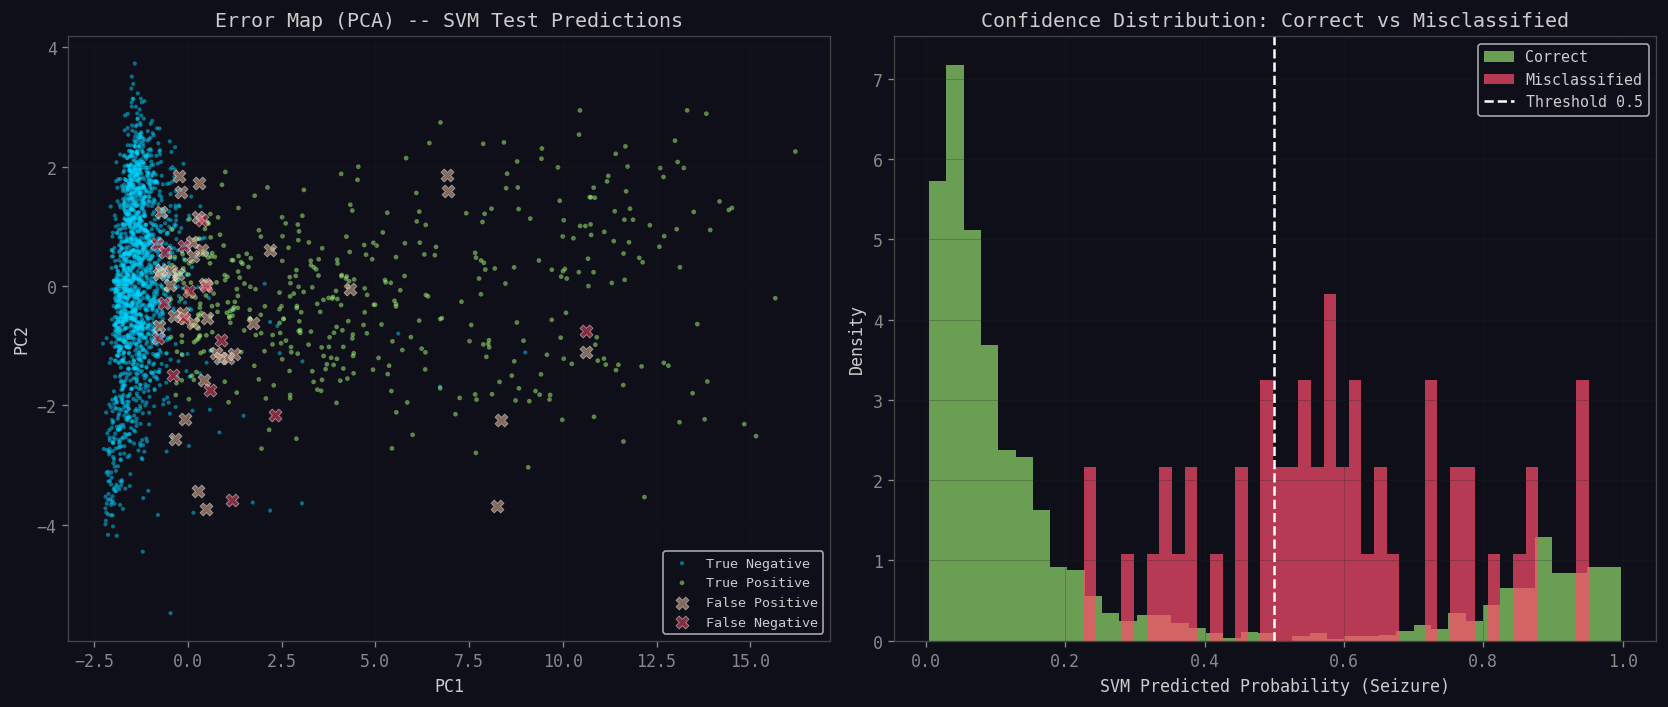

In [89]:
# -- Feature-space view of errors --
pca_test = PCA(n_components=2, random_state=SEED).fit_transform(X_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for label, mask, color, marker, size in [
    ('True Negative',  (y_test==0)&correct,  PALETTE[0], 'o', 6),
    ('True Positive',  (y_test==1)&correct,  PALETTE[2], 'o', 8),
    ('False Positive', fp_mask,               PALETTE[3], 'X', 60),
    ('False Negative', fn_mask,               PALETTE[1], 'X', 60),
]:
    ax.scatter(pca_test[mask, 0], pca_test[mask, 1],
               c=color, label=label, alpha=0.5, s=size, marker=marker,
               edgecolors='none' if size < 30 else '#fff', linewidths=0.5)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Error Map (PCA) -- SVM Test Predictions', color='#ccc')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

ax = axes[1]
ax.hist(proba_best[correct],  bins=40, alpha=0.6, color=PALETTE[2], label='Correct',       density=True)
ax.hist(proba_best[~correct], bins=40, alpha=0.7, color=PALETTE[1], label='Misclassified', density=True)
ax.axvline(0.5, color='white', lw=1.5, ls='--', label='Threshold 0.5')
ax.set_xlabel('SVM Predicted Probability (Seizure)')
ax.set_ylabel('Density')
ax.set_title('Confidence Distribution: Correct vs Misclassified', color='#ccc')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:
# -- Feature comparison: correct detections vs missed seizures --
fn_features      = X_test[fn_mask]
correct_pos_mask = (y_test == 1) & correct
correct_features = X_test[correct_pos_mask]

print('Feature comparison: correctly detected seizures vs missed seizures')
print(f'{"Feature":<18} {"Correct mean":>14} {"Missed mean":>14} {"Difference":>12}')
print('-' * 62)
for i, fname in enumerate(FEATURE_NAMES):
    c_mean = correct_features[:, i].mean()
    m_mean = fn_features[:, i].mean() if fn_features.shape[0] > 0 else float('nan')
    diff   = m_mean - c_mean
    if abs(diff) > 0.3:
        print(f'{fname:<18} {c_mean:>14.3f} {m_mean:>14.3f} {diff:>+12.3f}')

Feature comparison: correctly detected seizures vs missed seizures
Feature              Correct mean    Missed mean   Difference
--------------------------------------------------------------
std                         1.696          0.394       -1.302
skewness                   -0.180          0.970       +1.150
kurtosis                    0.123          0.709       +0.586
min                        -1.538         -0.048       +1.490
max                         1.521          0.677       -0.844
range                       1.617          0.361       -1.256
rms                         1.682          0.400       -1.282
zcr                         0.074         -0.492       -0.566
q1                         -1.530         -0.473       +1.057
q3                          1.565          0.018       -1.547
mad                         1.692          0.177       -1.516
theta_power                 1.302         -0.048       -1.350
alpha_power                 1.155         -0.123       -1.278
be

## 12. Statistical Significance: McNemar's Test

McNemar's test determines whether two classifiers make **statistically different errors** on the same test set.
A p-value < 0.05 means the difference is statistically significant.

In [91]:
from scipy.stats import chi2

def mcnemar_test(preds_a, preds_b, y_true):
    b = np.sum((preds_a == y_true) & (preds_b != y_true))
    c = np.sum((preds_a != y_true) & (preds_b == y_true))
    if (b + c) == 0: return 0.0, 1.0
    stat  = (abs(b - c) - 1) ** 2 / (b + c)
    p_val = 1 - chi2.cdf(stat, df=1)
    return stat, p_val

model_names = list(results.keys())
n_models    = len(model_names)

print('McNemar Test p-values (p < 0.05 = significant difference)')
print()
header = f'{"":22s}' + ''.join([f'{n[:10]:>12s}' for n in model_names])
print(header)
print('-' * (22 + 12 * n_models))

p_matrix = np.ones((n_models, n_models))
for i, name_a in enumerate(model_names):
    row = f'{name_a[:20]:<22s}'
    for j, name_b in enumerate(model_names):
        if i == j:
            row += f'{"---":>12s}'
        elif j > i:
            stat, p = mcnemar_test(results[name_a]['preds'], results[name_b]['preds'], y_test)
            p_matrix[i, j] = p
            marker = '*' if p < 0.05 else ' '
            row += f'{p:.4f}{marker:>2s}'.rjust(12)
        else:
            row += f'{"":>12s}'
    print(row)
print('\n* = statistically significant (p < 0.05)')

McNemar Test p-values (p < 0.05 = significant difference)

                        Logistic R         LDA  Perceptron  Kernel SVM         MLP
----------------------------------------------------------------------------------
Logistic Regression            ---    0.3057      0.2679      0.0009 *    0.0001 *
LDA                                        ---    1.0000      0.0000 *    0.0000 *
Perceptron                                             ---    0.0000 *    0.0000 *
Kernel SVM (RBF)                                                   ---    0.6265  
MLP                                                                            ---

* = statistically significant (p < 0.05)


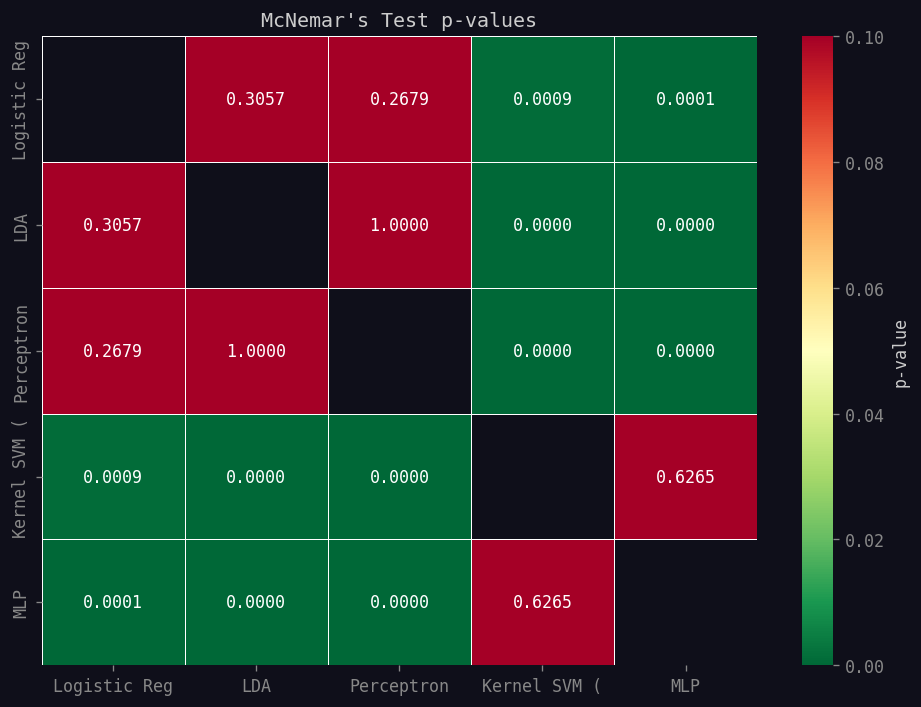

In [92]:
# -- McNemar heatmap --
fig, ax = plt.subplots(figsize=(8, 6))
p_display = np.full((n_models, n_models), np.nan)
for i in range(n_models):
    for j in range(i+1, n_models):
        p_display[i, j] = p_matrix[i, j]
        p_display[j, i] = p_matrix[i, j]
mask = np.eye(n_models, dtype=bool)
sns.heatmap(p_display, annot=True, fmt='.4f', cmap='RdYlGn_r',
            xticklabels=[n[:12] for n in model_names],
            yticklabels=[n[:12] for n in model_names],
            mask=mask, ax=ax, vmin=0, vmax=0.1,
            linewidths=0.5, cbar_kws={'label': 'p-value'})
ax.set_title("McNemar's Test p-values", color='#ccc')
plt.tight_layout()
plt.show()

In [93]:
# -- Pairwise significance summary --
print('Pairwise significance summary:')
for i, name_a in enumerate(model_names):
    for j, name_b in enumerate(model_names):
        if j > i:
            stat, p = mcnemar_test(results[name_a]['preds'], results[name_b]['preds'], y_test)
            sig = 'SIGNIFICANT' if p < 0.05 else 'not significant'
            print(f'  {name_a:25s} vs {name_b:25s} | p={p:.4f} | {sig}')

Pairwise significance summary:
  Logistic Regression       vs LDA                       | p=0.3057 | not significant
  Logistic Regression       vs Perceptron                | p=0.2679 | not significant
  Logistic Regression       vs Kernel SVM (RBF)          | p=0.0009 | SIGNIFICANT
  Logistic Regression       vs MLP                       | p=0.0001 | SIGNIFICANT
  LDA                       vs Perceptron                | p=1.0000 | not significant
  LDA                       vs Kernel SVM (RBF)          | p=0.0000 | SIGNIFICANT
  LDA                       vs MLP                       | p=0.0000 | SIGNIFICANT
  Perceptron                vs Kernel SVM (RBF)          | p=0.0000 | SIGNIFICANT
  Perceptron                vs MLP                       | p=0.0000 | SIGNIFICANT
  Kernel SVM (RBF)          vs MLP                       | p=0.6265 | not significant


# 13. Discussion and Conclusions

## Summary of Results

| Model | Test Acc | Test F1 | Test AUC | CV F1 (mean +/- std) |
|---|---|---|---|---|
| Logistic Regression | 0.9648 | 0.9152 | 0.9899 | 0.9206 +/- 0.0078 |
| LDA | 0.9609 | 0.9026 | 0.9898 | 0.9137 +/- 0.0087 |
| Perceptron | 0.9604 | 0.9085 | 0.9941 | 0.8865 +/- 0.0194 |
| Kernel SVM (RBF) | 0.9778 | 0.9458 | 0.9962 | -- |
| MLP | 0.9796 | 0.9506 | 0.9977 | 0.9418 +/- 0.0052 |

## Key Findings

**Non-linear models perform best.** The Kernel SVM and MLP outperform all three linear classifiers by about 3.5 F1 points on the test set. McNemar's test confirms this gap is statistically significant (p < 0.001 for all linear vs. non-linear pairs), which means the decision boundary in the 19-feature space is genuinely non-linear. SVM and MLP are statistically indistinguishable from each other (p = 0.6265), so neither is clearly better.

**Linear models perform similarly to each other.** Logistic Regression, LDA, and Perceptron show no significant pairwise differences (McNemar p = 0.31, 0.27, and 1.00). Logistic Regression edges out LDA and Perceptron in F1 (0.9152 vs. 0.9026 and 0.9085), likely because mini-batch gradient descent with L2 regularization (lambda = 0.001) finds a better weight vector than LDA's closed-form projection or the Perceptron's hard-margin updates. The Perceptron also shows the highest cross-validation variance (+/- 0.0194), which reflects its sensitivity to learning rate and update order.

**Class imbalance was handled without oversampling.** Cost-sensitive weighting (w_seizure = 4.0, w_non-seizure = 1.0) kept the 20% seizure rate consistent across all splits and directly penalized missed seizures during training. This avoided the risk of SMOTE introducing synthetic artifacts into time-series feature distributions.

**Threshold tuning gives modest but real gains.** Choosing a better decision threshold using the validation set improved test F1 for Logistic Regression (+0.0082, threshold = 0.66) and MLP (+0.0054, threshold = 0.87). The MLP's high optimal threshold shows that the model is confident in its seizure predictions and needs strong evidence before classifying a sample as a seizure. LDA and Perceptron saw no improvement because their probability outputs are less well-calibrated.

**Error analysis reveals two clear failure modes.** For the best model (Kernel SVM), the 15 false negatives (missed seizures) share a distinct feature profile: much lower amplitude (std -1.302, range -1.256, RMS -1.282 compared to correctly detected seizures), positive skewness (+1.150), and lower spectral power across all frequency bands. These are likely low-amplitude or atypical seizure events that look too similar to resting EEG. The 36 false positives are mostly Class 2 (Tumor-area EEG, 22 of 36), which shares high-amplitude, broad-spectrum characteristics with seizure signals. This is a clinically interpretable failure mode.

**The Approximate Entropy (ApEn) feature is statistically validated.** A two-sample t-test confirms that seizure EEG has higher ApEn than non-seizure EEG (t = -17.503, p = 1.03e-67). Seizure signals (mean ApEn = 0.337) are more complex in the Takens phase-space sense than resting EEG (mean ApEn = 0.299), even though they look more rhythmically regular in raw waveform plots. The Takens embedding portraits support this: seizure phase-space trajectories spread across a larger, more diffuse attractor. In logistic regression feature importance, ApEn ranks in the middle tier, secondary to amplitude-based features like delta_power, std, and RMS, which carry the primary discriminative load.

## Future Work

- Multi-scale wavelet decomposition (Daubechies db4) for richer sub-band features beyond the five FFT bands used here
- 5-class formulation to distinguish EEG brain regions, which may reduce tumor-area false positives
- Temporal context across adjacent 1-second windows using recurrent models (LSTM, GRU), since the current pipeline treats each window independently
- Sample Entropy and Multiscale Entropy as more robust alternatives to ApEn, especially for short EEG windows
- Subject-independent cross-validation to test generalization across patients rather than across windows from the same recording

In [94]:
# -- Final summary --
print('\n' + '='*60)
print('  FINAL TEST RESULTS SUMMARY')
print('='*60)
for model_name, res in results.items():
    print(f'  {model_name:25s}  Acc={res["acc"]:.4f}  F1={res["f1"]:.4f}  AUC={res["auc"]:.4f}')
print('='*60)
print()
print('--- Tuned Threshold Results ---')
for model_name, res in tuned_results.items():
    print(f'  {model_name:25s}  F1={res["f1"]:.4f}  Thresh={res["thresh"]:.2f}')


  FINAL TEST RESULTS SUMMARY
  Logistic Regression        Acc=0.9648  F1=0.9152  AUC=0.9899
  LDA                        Acc=0.9609  F1=0.9026  AUC=0.9898
  Perceptron                 Acc=0.9604  F1=0.9085  AUC=0.9941
  Kernel SVM (RBF)           Acc=0.9778  F1=0.9458  AUC=0.9962
  MLP                        Acc=0.9796  F1=0.9506  AUC=0.9977

--- Tuned Threshold Results ---
  Logistic Regression        F1=0.9234  Thresh=0.66
  LDA                        F1=0.9026  Thresh=0.50
  Perceptron                 F1=0.9085  Thresh=0.50
  Kernel SVM (RBF)           F1=0.9440  Thresh=0.49
  MLP                        F1=0.9560  Thresh=0.87
